In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans

MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH: str = "..\\data\\original.csv"

df = pd.read_csv(MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH, sep=";", decimal=",")

# Exploratory Data Analysis
## Initial Cleanup
Some issues with the data were fixed in excel manually. These include:
- Table was not aligned to the top left.
- A span of ~400 rows was shifted to the right.

We decided to remove columns with invalid or missing values completely, as there were only 122 such rows. The values appeard to be missing completely at random.

In [2]:
# Coerce invalid values to NaN
object_feature_columns = ["Magnesium_mg", "VitE_mg"]
coerced_count = 0
for col in object_feature_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    coerced_count += np.sum(df[col].isna())
print(f"Coerced {coerced_count} values to NaN in columns {object_feature_columns}.")

# Remove rows with NaN values
row_has_none = df.isna().any(axis=1)
df = df.dropna()
print(f"Dropped {sum(row_has_none)} rows with missing values.")

# Define numeric columns for future use
num_cols = df.select_dtypes("number").columns

# Coercing duplicate rows
grouped_rows = list(df.groupby("NDB_No", dropna=False, sort=False))
original_row_count = len(df)
merged_rows = []
for ndb_no, group in grouped_rows:
    if len(group) != 1:
        for column in df.columns:
            if group[column].astype(str).nunique() != 1:
                raise ValueError(f"Multiple non-matching rows found for NDB_NO: {ndb_no}")

    merged_rows.append(group.iloc[0])

df = pd.DataFrame(merged_rows, columns=df.columns).reset_index(drop=True)
print(f"Removed {original_row_count - len(df)} duplicate rows.")

# Convert micro-/mili-grams to grams (automatic, based on suffixes)
suffix_map = {"_mg": 1e-3, "_mcg": 1e-6}
converted = []
for col in list(df.columns):
    for suf, factor in suffix_map.items():
        if col.endswith(suf):
            base = col.rsplit("_", 1)[0]
            new_col = f"{base}_g"
            # ensure numeric before conversion
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[new_col] = df[col] * factor
            converted.append((col, new_col))
            # drop the original suffixed column after conversion
            df.drop(columns=[col], inplace=True)
            break

print(f"Converted {len(converted)} columns: {converted}")

# Recompute numeric columns
num_cols = df.select_dtypes("number").columns.tolist()

Coerced 15 values to NaN in columns ['Magnesium_mg', 'VitE_mg'].
Dropped 122 rows with missing values.
Removed 916 duplicate rows.
Converted 20 columns: [('Calcium_mg', 'Calcium_g'), ('Iron_mg', 'Iron_g'), ('Magnesium_mg', 'Magnesium_g'), ('Phosphorus_mg', 'Phosphorus_g'), ('Potassium_mg', 'Potassium_g'), ('Sodium_mg', 'Sodium_g'), ('Zinc_mg', 'Zinc_g'), ('Copper_mcg', 'Copper_g'), ('Manganese_mg', 'Manganese_g'), ('Selenium_mcg', 'Selenium_g'), ('VitC_mg', 'VitC_g'), ('Thiamin_mg', 'Thiamin_g'), ('Riboflavin_mg', 'Riboflavin_g'), ('Niacin_mg', 'Niacin_g'), ('VitB6_mg', 'VitB6_g'), ('Folate_mcg', 'Folate_g'), ('VitB12_mcg', 'VitB12_g'), ('VitA_mcg', 'VitA_g'), ('VitE_mg', 'VitE_g'), ('VitD2_mcg', 'VitD2_g')]


## Outliers
Most features have visible outliers, we will need to resolve those later.

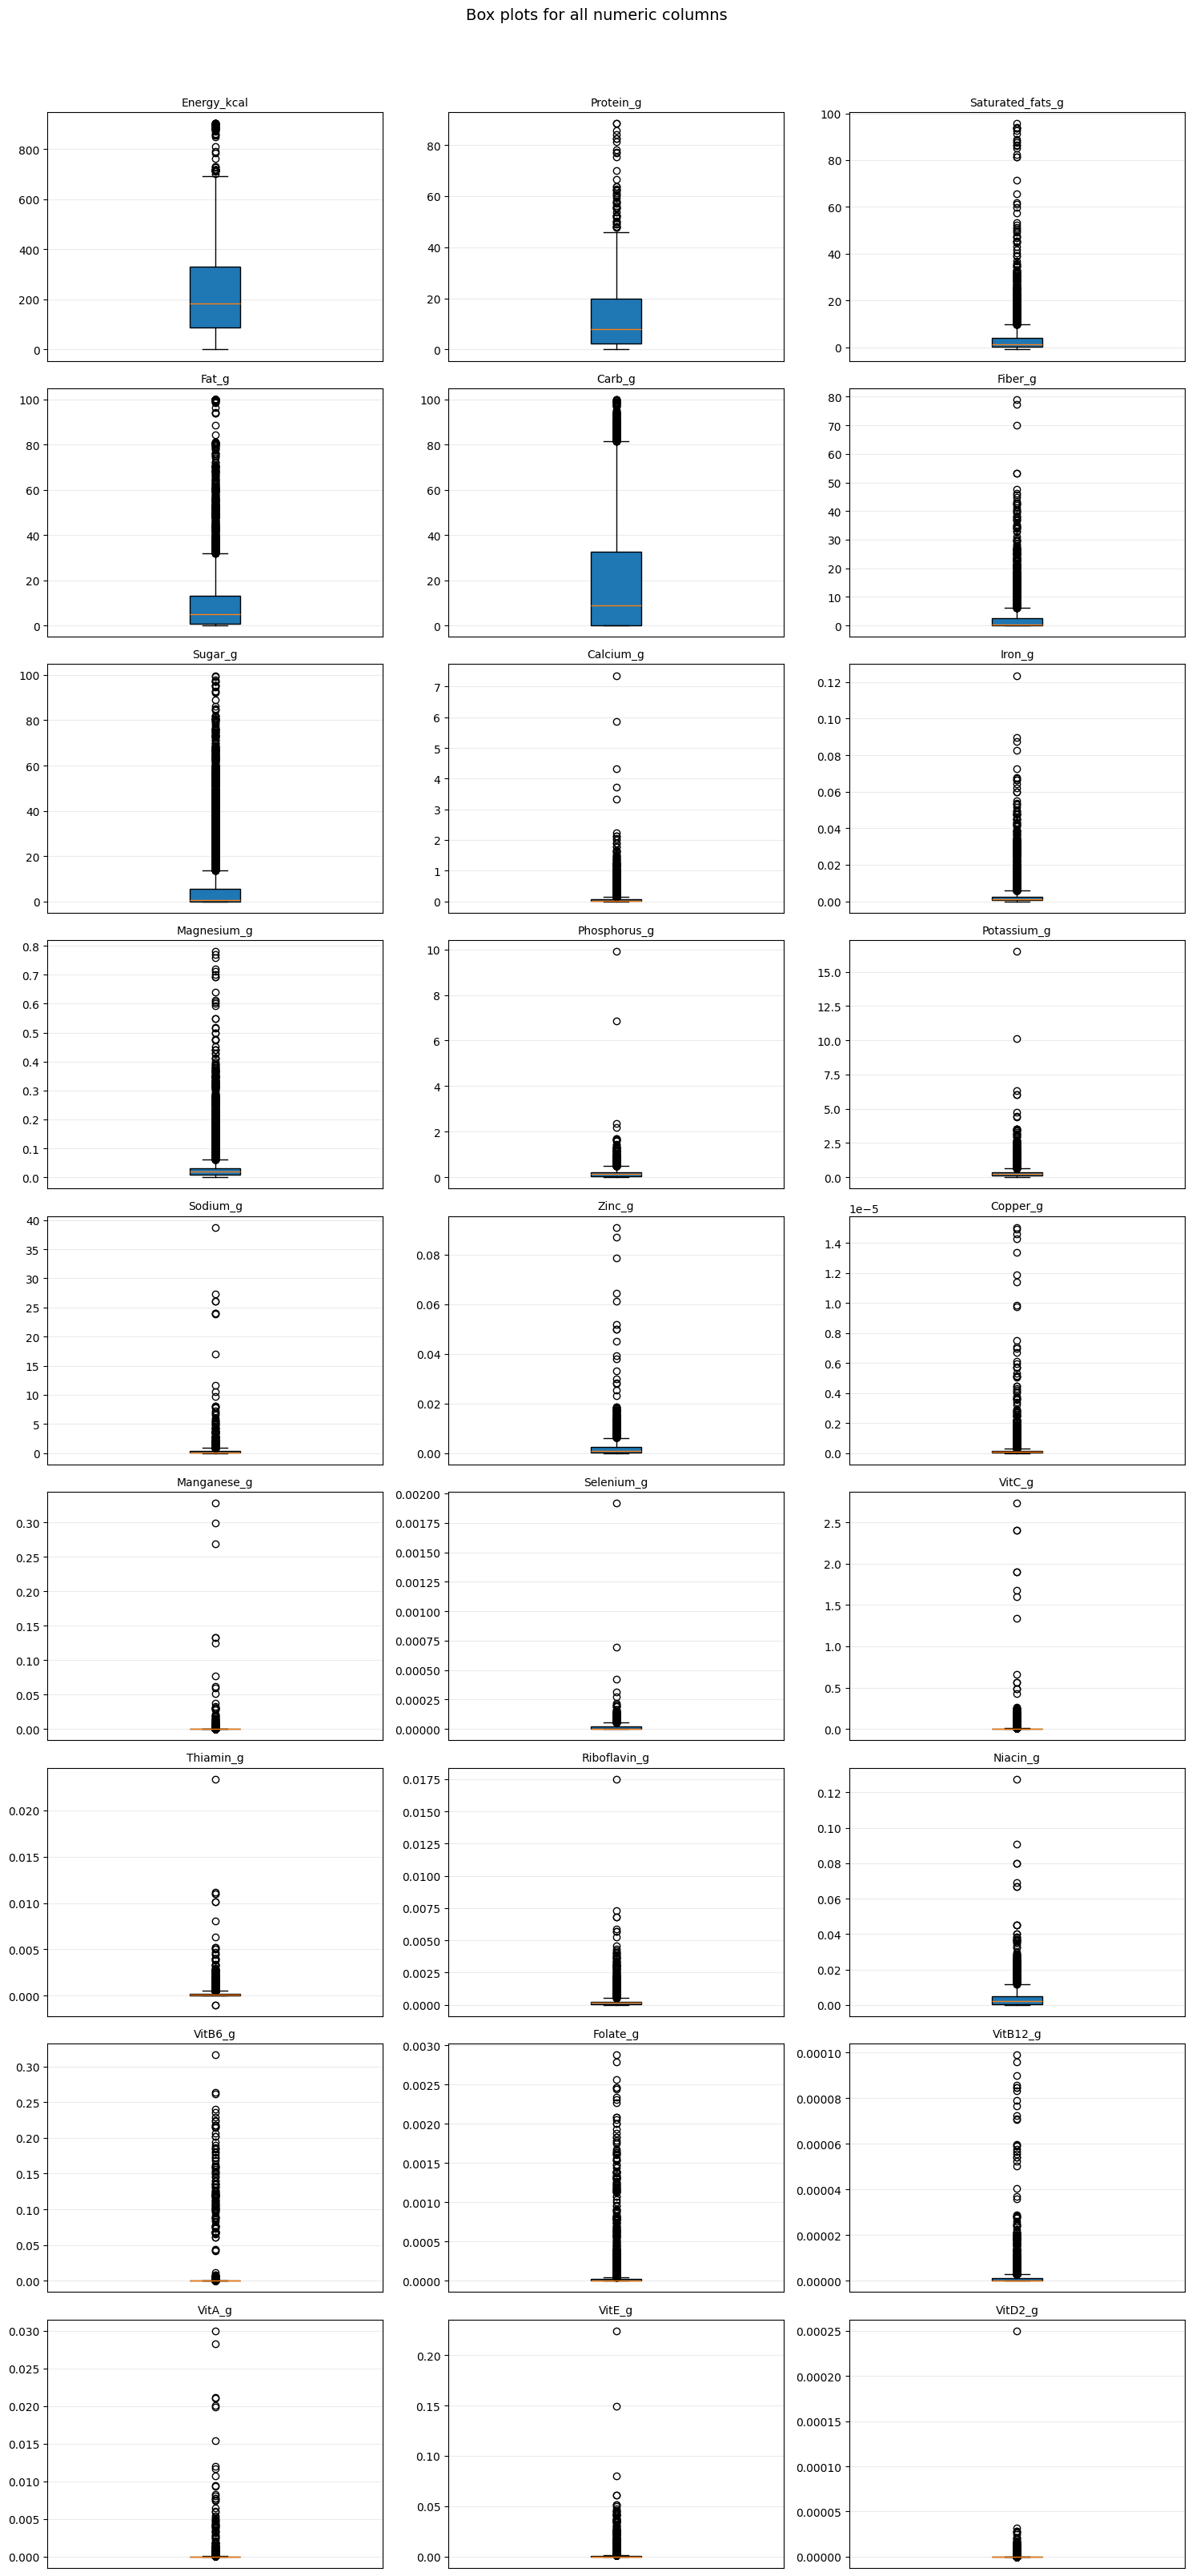

In [3]:
# Box plots for all numeric columns
numeric_data = df[num_cols]
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, column in zip(axes, num_cols):
    series = numeric_data[column].dropna()
    ax.boxplot(series, vert=True, patch_artist=True)
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(num_cols):]:
    ax.axis("off")

fig.suptitle("Box plots for all numeric columns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Pyramid charts
- Idea taken from Hynek Vaverka group's first presentation.
- We can see most foods recpect the minimum calory estimate:
$$\text{kcal} \ge 4\cdot \text{carbs} + 4\cdot \text{protein} + 9\cdot \text{fat}$$
- However, some foods are in forbidden regions of the graphs (a food can't have 100 grams of carbs but 0 calories).

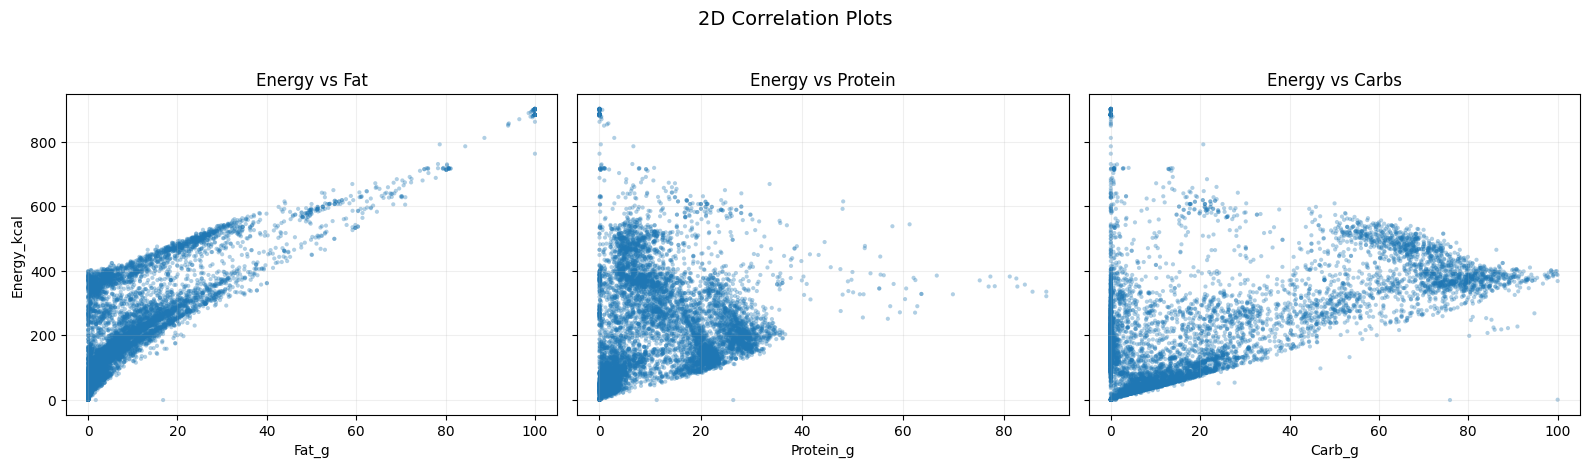

In [4]:
# Simple 2D plots for Energy vs macronutrients (pyramid-like patterns)
pairs = [
    ("Fat_g", "Energy vs Fat"),
    ("Protein_g", "Energy vs Protein"),
    ("Carb_g", "Energy vs Carbs"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (x_col, title) in zip(axes, pairs):
    plot_df = df[[x_col, "Energy_kcal"]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df["Energy_kcal"] = pd.to_numeric(plot_df["Energy_kcal"], errors="coerce")
    plot_df = plot_df.dropna()

    ax.scatter(
        plot_df[x_col],
        plot_df["Energy_kcal"],
        s=9,
        alpha=0.35,
        edgecolors="none"
    )
    ax.set_xlabel(x_col)
    ax.set_title(title)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Energy_kcal")
fig.suptitle("2D Correlation Plots", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## Feature Correlation

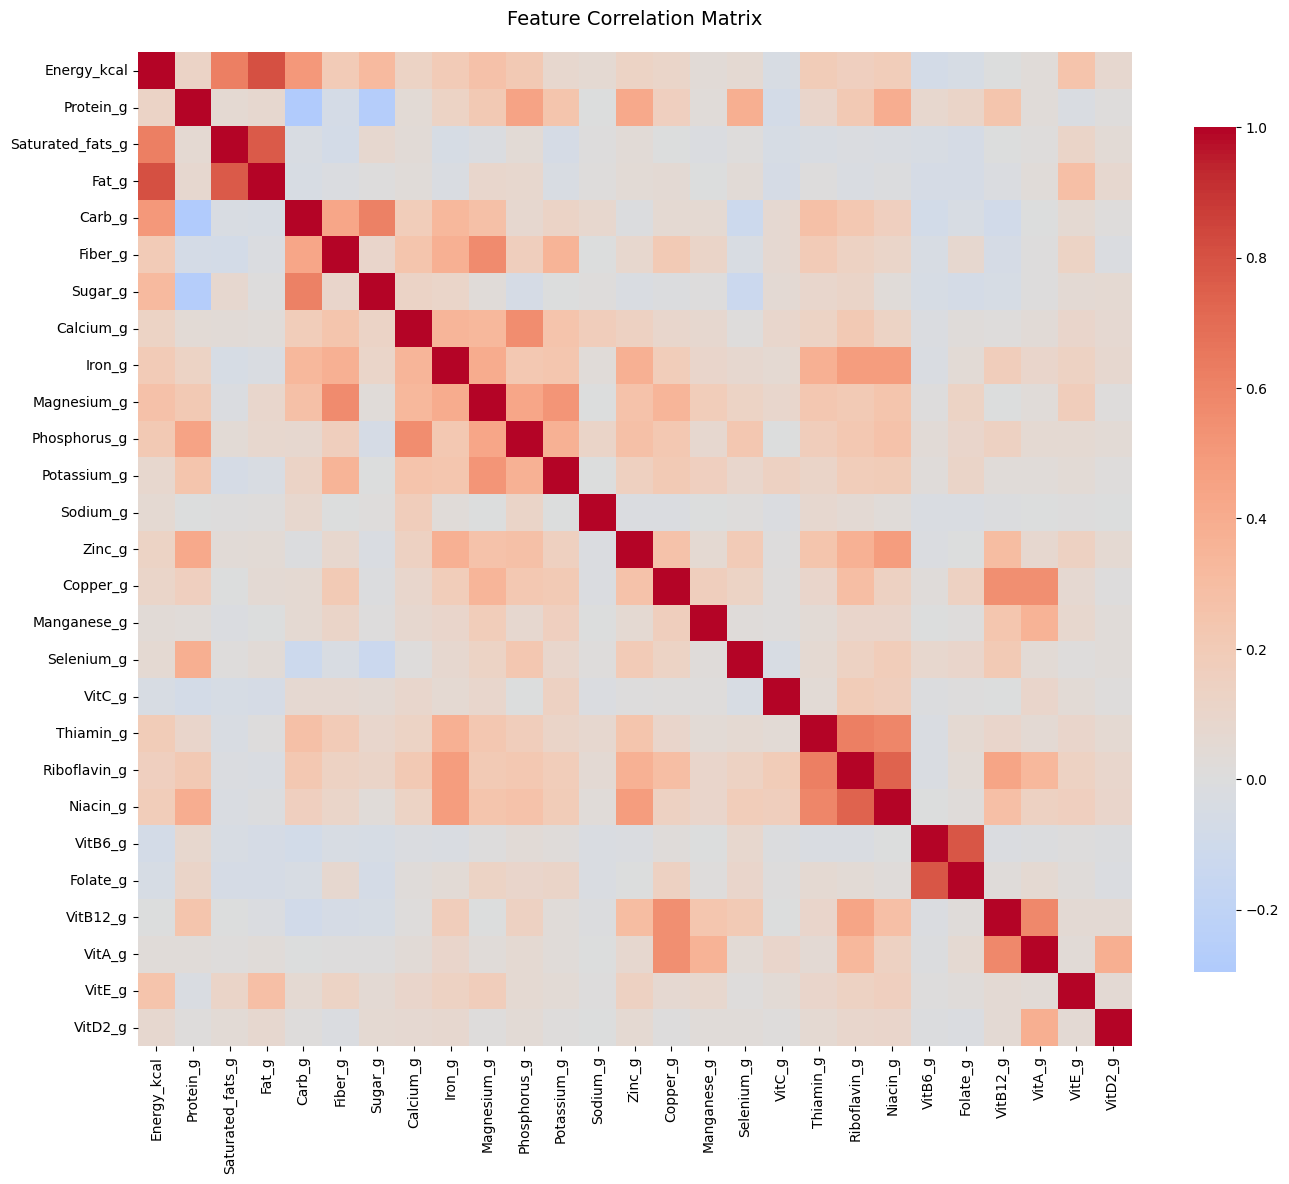

Highly correlated pairs (>0.95): 0


In [5]:
# Compute correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"Highly correlated pairs (>0.95): {len(high_corr_pairs)}")
for col1, col2, val in high_corr_pairs[:5]:
    print(f"  {col1} <-> {col2}: {val:.3f}")

# Preprocessing

## Outliers
- Clamp negative values
- Use the Atwater nutrient equation to remove extreme outliers

In [6]:
# Start with numeric features, drop ID columns
X = df.select_dtypes(include="number").drop(columns=["NDB_No"], errors="ignore").copy()
print(f"Initial shape: {X.shape}")

# Clamp negative values to 0
neg_count = int((X < 0).sum().sum())
X = X.clip(lower=0)
print(f"Clamped {neg_count} negative values to 0")

# Remove rows violating the energy equation: kcal >= 4*carbs + 4*protein + 9*fat
ENERGY_THRESHOLD_RATIO = 1.25
ENERGY_THRESHOLD_ABSOLUTE = 50
projected_energy = (4 * X['Carb_g'] + 4 * X['Protein_g'] + 9 * X['Fat_g'])

# Keep only rows where observed energy falls within the expected energy
mask = (X['Energy_kcal'] < projected_energy * ENERGY_THRESHOLD_RATIO) & \
       (X['Energy_kcal'] > projected_energy / ENERGY_THRESHOLD_RATIO) & \
       (abs(X['Energy_kcal'] - projected_energy) > ENERGY_THRESHOLD_ABSOLUTE)
X = X[~mask]

print(f"Removed {int((mask).sum())} rows violating energy equation.")

Initial shape: (9213, 27)
Clamped 10 negative values to 0
Removed 57 rows violating energy equation.


## Feature Engineering
- Nutrient ratios
- Mineral and Vitamin densities

In [7]:
# Create engineered features on the cleaned data
X_eng = X.copy()

# If feature is 0, ratio is 0.
X_eng['Protein_per_kcal'] = np.where(X_eng['Energy_kcal'] == 0, 0, X_eng['Protein_g'] / X_eng['Energy_kcal'])
X_eng['Fiber_Carb_ratio'] = np.where(X_eng['Carb_g'] == 0, 0, X_eng['Fiber_g'] / X_eng['Carb_g'])
X_eng['Saturated_fat_ratio'] = np.where(X_eng['Fat_g'] == 0, 0, X_eng['Saturated_fats_g'] / X_eng['Fat_g'])

# Mineral and vitamin densities
minerals = [c for c in X_eng.columns if any(x in c.lower() for x in ['calcium', 'iron', 'magnesium', 'phosphorus', 'potassium', 'sodium', 'zinc', 'copper', 'manganese', 'selenium'])]
vitamins = [c for c in X_eng.columns if any(x in c.lower() for x in ['vit', 'thiamin', 'riboflavin', 'niacin', 'folate'])]

# Scale minerals to 0-1 range first, then sum so trace minerals have equal weight
X_eng['Mineral_density'] = MinMaxScaler().fit_transform(X_eng[minerals]).sum(axis=1)
X_eng['Vitamin_density'] = MinMaxScaler().fit_transform(X_eng[vitamins]).sum(axis=1)


engineered_cols = [c for c in X_eng.columns if c not in X.columns]
print(f"Created {len(engineered_cols)} engineered features: {engineered_cols}")
print(f"Total features: {X_eng.shape[1]}")


Created 5 engineered features: ['Protein_per_kcal', 'Fiber_Carb_ratio', 'Saturated_fat_ratio', 'Mineral_density', 'Vitamin_density']
Total features: 32


## Log1p Transform of Higly Skewd Columns
Most foods contain zero or trace amounts of specific micronutrients, while a few "superfoods" possess massive, outlier concentrations. Because K-Means clustering is highly vulnerable to extreme values, we applied this transformation to compress the extreme tails of the data without breaking natural zero-counts. This is a standard practice in nutritional informatics, ensuring that extreme micronutrient outliers (like liver or fortified cereals) do not artificially hijack and collapse the clusters.

In [8]:
# Create log1p-transformed copy (on skewed columns)
X_log1p = X_eng.copy()

# Identify columns with high positive skew
SKEW_THRESHOLD = 1.5
skew_vals = X_eng.skew(numeric_only=True)  # Only check non-engineered features
log_cols = skew_vals[skew_vals > SKEW_THRESHOLD].index.tolist()

if log_cols:
    X_log1p[log_cols] = np.log1p(X_log1p[log_cols])
    print(f"Applied log1p to {len(log_cols)} skewed columns: {log_cols}")
else:
    print("No columns above skew threshold")

print(f"Shape: {X_log1p.shape}")

Applied log1p to 27 skewed columns: ['Saturated_fats_g', 'Fat_g', 'Fiber_g', 'Sugar_g', 'Calcium_g', 'Iron_g', 'Magnesium_g', 'Phosphorus_g', 'Potassium_g', 'Sodium_g', 'Zinc_g', 'Copper_g', 'Manganese_g', 'Selenium_g', 'VitC_g', 'Thiamin_g', 'Riboflavin_g', 'Niacin_g', 'VitB6_g', 'Folate_g', 'VitB12_g', 'VitA_g', 'VitE_g', 'VitD2_g', 'Fiber_Carb_ratio', 'Mineral_density', 'Vitamin_density']
Shape: (9156, 32)


## Standard Scaler
By standardizing the data, we ensure that every feature is weighted equally. This step is crucial and heavily utilized in dietary epidemiology, as it guarantees that a food's trace mineral profile has the same mathematical influence on its final classification as its bulk macronutrients.

In [9]:
X_log1p_scaled = X_log1p.copy()

scaler = StandardScaler()
X_log1p_scaled = pd.DataFrame(
    scaler.fit_transform(X_log1p),
    index=X_log1p.index,
    columns=X_log1p.columns,
)

X_preprocessed = X_log1p_scaled.copy()

print(f"Shape after preprocessing: {X_preprocessed.shape}")

Shape after preprocessing: (9156, 32)


# Models

## Shared Functions

In [10]:
def evaluate_and_visualize_clusters(raw_data, scaled_data, labels):
    """
    Takes readable data (for stats) and scaled data (for distance metrics), 
    plus cluster labels. Plots a 3x2 grid:
    Top: Pie Chart | t-SNE
    Mid: Silhouette Plot | Macronutrient Pyramid
    Bot: Radar Chart | Violin Plot
    """
    # 1. Prepare the DataFrames
    df_raw = pd.DataFrame(raw_data).copy()
    df_scaled = pd.DataFrame(scaled_data).copy()
        
    df_raw['Cluster'] = labels
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # ==========================================
    # GLOBAL COLOR & ALIAS MAPPING
    # ==========================================
    aliases = {label: f"C{i}" for i, label in enumerate(unique_labels)}
    df_raw['Alias'] = df_raw['Cluster'].map(aliases)
    
    colors = sns.color_palette("husl", n_clusters)
    palette = dict(zip(unique_labels, colors))
    palette_alias = {aliases[k]: v for k, v in palette.items()} 
    
    # ==========================================
    # 2. CALCULATE AND PRINT STATISTICS
    # ==========================================
    print("=" * 50)
    print("CLUSTER SIZE STATISTICS")
    print("=" * 50)
    
    cluster_counts = df_raw['Cluster'].value_counts().sort_index()
    cluster_percentages = (cluster_counts / len(df_raw)) * 100
    
    stats_df = pd.DataFrame({
        'Alias': [aliases[idx] for idx in cluster_counts.index],
        'Size (Rows)': cluster_counts,
        'Percentage (%)': cluster_percentages.round(2)
    })
    print(stats_df.to_string())
    print("\n")
    
    # ==========================================
    # 3. DIMENSIONALITY REDUCTION & SILHOUETTE
    # ==========================================
    tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
    tsne_result = tsne.fit_transform(df_scaled)
    
    # Calculate global and per-sample silhouette scores
    silhouette_avg = silhouette_score(df_scaled, labels)
    sample_silhouette_values = silhouette_samples(df_scaled, labels)
    
    # ==========================================
    # 4. BUILD THE 3x2 DASHBOARD
    # ==========================================
    fig = plt.figure(figsize=(18, 22)) 
    fig.suptitle('Comprehensive Cluster Analysis Dashboard', fontsize=24, fontweight='bold', y=0.98)
    
    # --- Plot 1 (Top Left): Pie Chart ---
    ax1 = fig.add_subplot(3, 2, 1)
    pie_colors = [palette[val] for val in cluster_counts.index]
    ax1.pie(
        cluster_counts, labels=[aliases[idx] for idx in cluster_counts.index], 
        autopct='%1.1f%%', colors=pie_colors, startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    ax1.set_title('Cluster Distribution', fontsize=16)
    
    # --- Plot 2 (Top Right): t-SNE ---
    ax2 = fig.add_subplot(3, 2, 2)
    sns.scatterplot(
        x=tsne_result[:, 0], y=tsne_result[:, 1], 
        hue=df_raw['Alias'], palette=palette_alias, alpha=0.6, s=40, ax=ax2, legend=False
    )
    ax2.set_title('Local Neighborhoods (t-SNE)', fontsize=16)
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    
    # --- Plot 3 (Mid Left): Silhouette Plot ---
    ax3 = fig.add_subplot(3, 2, 3)
    y_lower = 10
    
    for label in unique_labels:
        # Aggregate and sort silhouette scores for this cluster
        ith_cluster_silhouette_values = sample_silhouette_values[labels == label]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = palette[label]
        ax3.fill_betweenx(
            np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
            facecolor=color, edgecolor=color, alpha=0.7
        )

        # Label the clusters in the middle of their silhouette "blade"
        ax3.text(-0.05, y_lower + 0.5 * size_cluster_i, aliases[label], fontsize=12, va='center', ha='right')
        y_lower = y_upper + 10  # Gap between clusters

    ax3.set_title("Silhouette Plot of Clusters", fontsize=16)
    ax3.set_xlabel("Silhouette Coefficient Values")
    ax3.set_ylabel("Cluster Alias (Thickness = Size)")
    ax3.axvline(x=silhouette_avg, color="red", linestyle="--") # Global average line
    ax3.set_yticks([])  # Clear the y-axis ticks to keep it clean
    
    # --- Plot 4 (Mid Right): Macronutrient Caloric Breakdown ---
    ax4 = fig.add_subplot(3, 2, 4)
    medians = df_raw.groupby('Cluster').median(numeric_only=True)
    
    macro_cals = pd.DataFrame({
        'Carb_cals': medians['Carb_g'] * 4,
        'Protein_cals': medians['Protein_g'] * 4,
        'Fat_cals': medians['Fat_g'] * 9 
    })
    macro_totals = macro_cals.sum(axis=1).replace(0, 1) 
    macro_pct = macro_cals.div(macro_totals, axis=0) * 100
    macro_pct.index = [aliases[label] for label in macro_pct.index]
    
    macro_pct.plot(
        kind='bar', stacked=True, ax=ax4, 
        color=['#FFB347', '#FF6961', '#77DD77'], edgecolor='black', linewidth=1.2
    )
    ax4.set_title('Median Macronutrient Energy Breakdown', fontsize=16)
    ax4.set_ylabel('% of Calculated Calories')
    ax4.legend(['Carbs', 'Protein', 'Fat'], loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)
    ax4.tick_params(axis='x', rotation=0)

    # --- Plot 5 (Bottom Left): Radar Chart (Spider Plot) ---
    ax5 = fig.add_subplot(3, 2, 5, polar=True)
    radar_features = ['Carb_g', 'Protein_g', 'Fat_g', 'Fiber_g', 'Sugar_g']
    radar_data = medians[radar_features]
    
    scaler = MinMaxScaler()
    radar_scaled = pd.DataFrame(scaler.fit_transform(radar_data), columns=radar_features, index=radar_data.index)
    
    N = len(radar_features)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] 
    ax5.set_theta_offset(np.pi / 2)
    ax5.set_theta_direction(-1)
    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(radar_features)
    
    for cluster_label in radar_scaled.index:
        values = radar_scaled.loc[cluster_label].values.flatten().tolist()
        values += values[:1] 
        ax5.plot(angles, values, linewidth=2, linestyle='solid', color=palette[cluster_label])
        ax5.fill(angles, values, color=palette[cluster_label], alpha=0.15)
        
    ax5.set_title('Normalized Macro Shape (Radar)', fontsize=16, pad=20)

    # --- Plot 6 (Bottom Right): Violin Plot ---
    ax6 = fig.add_subplot(3, 2, 6)
    sns.violinplot(
        x='Alias', y='Energy_kcal', data=df_raw, 
        hue='Alias', palette=palette_alias, density_norm='width', inner='quartile', ax=ax6, legend=False
    )
    ax6.set_title('Energy (kcal) Distribution Spread', fontsize=16)
    ax6.set_ylabel('Energy (kcal / 100g)')
    ax6.set_xlabel('Cluster Alias')
    
    # ==========================================
    # GLOBAL MASTER LEGEND
    # ==========================================
    global_patches = [mpatches.Patch(color=palette[label], label=f"{aliases[label]}: {label}") for label in unique_labels]
    legend_cols = min(4, len(unique_labels)) 
    fig.legend(handles=global_patches, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=legend_cols, fontsize=13)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
    plt.show()

## Baseline (Random)

Baseline Silhouette Score    : -0.0187
CLUSTER SIZE STATISTICS
        Alias  Size (Rows)  Percentage (%)
Cluster                                   
0          C0         1855           20.26
1          C1         1867           20.39
2          C2         1770           19.33
3          C3         1823           19.91
4          C4         1841           20.11




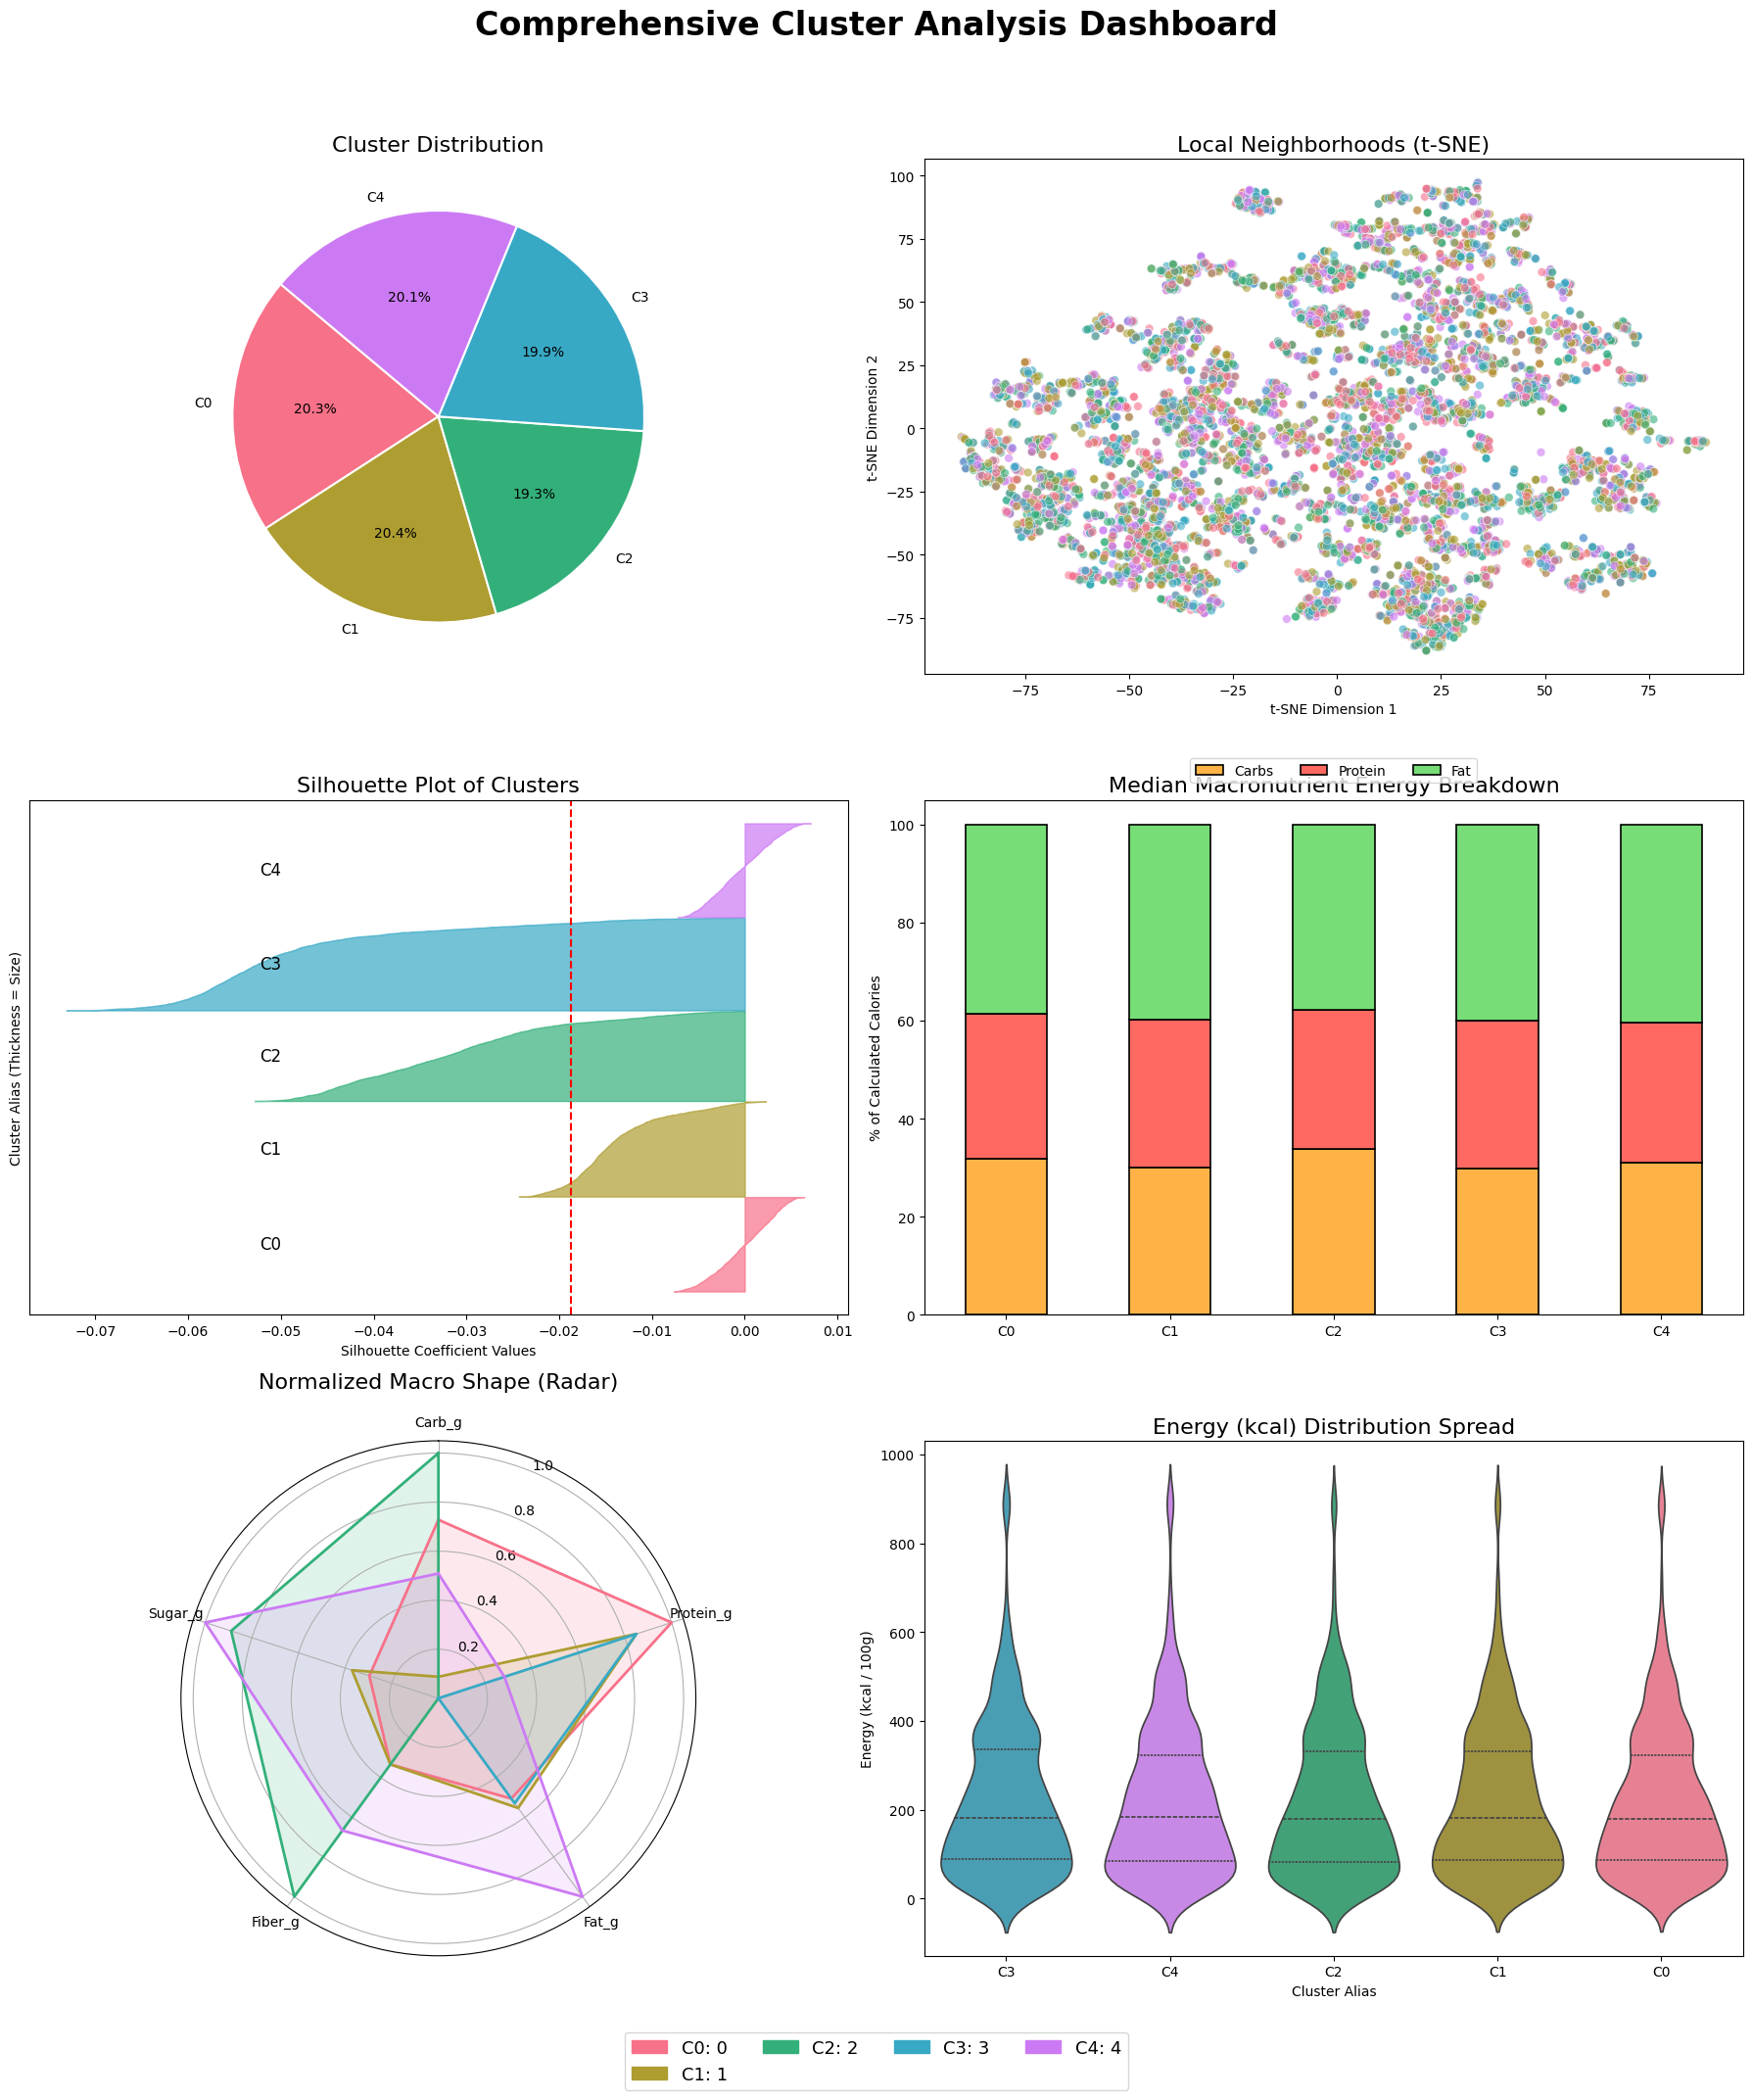

In [11]:
k = 5
n_samples = len(X_preprocessed)

np.random.seed(42)  # Set seed for reproducibility
random_labels = np.random.randint(0, k, size=n_samples)

baseline_silhouette = silhouette_score(X_preprocessed, random_labels)

print(f"Baseline Silhouette Score    : {baseline_silhouette:.4f}")
evaluate_and_visualize_clusters(X_eng, X_preprocessed, random_labels)

## DBSCAN (Euka)

The main goal of this section of the project was to identify an appropriate clustering structure using DBSCAN for the nutritional dataset. The focus was on tuning the key DBSCAN parameters — particularly eps and min_samples — to discover meaningful groupings of foods based on their nutrient profiles while minimizing noise and avoiding over- or under-clustering.

According to the research by Yongyu Wang, DBSCAN faces significant challenges in high-dimensional spaces because its computational complexity scales with the number of dimensions (D), making distance calculations increasingly resource-intensive and often computationally infeasible for large-scale analysis. 
While preprocessing is necessary to address these efficiency bottlenecks, Wang emphasizes that it also serves a critical qualitative purpose: by using methods like spectral data compression to remove substantial redundancy and noise, the algorithm can focus on the most essential structural information. As a result, this type of processing does not merely accelerate the execution but significantly enhances the quality and accuracy of the final clustering solutions.

According to documentation, PCA algorithm can reduce dimensionality, but reducing it too far (e.g., to 10 or fewer dimensions) often discards the very variance needed to distinguish clusters - due to its linear nature. UMAP is designed for non-linear manifold-aware dimension reduction, which can compress data into a very small number of dimensions (like 10) while preserving the cluster structure. Therefore, in this section UMAP preprocessing will be applied.

### Reducing dimensions

In [12]:
from umap import UMAP

# We use parameters optimized for clustering (pre-clustering)
umap_precluster = UMAP(
    n_neighbors=100,      # High value (30-100) to focus on global structure 
    min_dist=0.0,         # Set to 0 to pack points together densely for clustering
    n_components=10,      # Reduce to 10 dimensions to retain more variance than 2D 
    metric="euclidean",   # Standard distance metric used in the source examples
    random_state=43       # Ensures reproducibility of the results
)

# Transform the data to the new 10-dimensional space
X_umap = umap_precluster.fit_transform(X_preprocessed)

print(f"Original shape: {X_preprocessed.shape}")
print(f"Reduced shape: {X_umap.shape}")


c:\Users\tomas\Projects\courses\ib031\ib031-food-ingredients\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Original shape: (9156, 32)
Reduced shape: (9156, 10)


### Visualization

In this section, the dimensionally reduced dataset will be visualized using t-SNE and UMAP to examine potential clustering structures and identify natural groupings within the data.

CLUSTER SIZE STATISTICS
        Alias  Size (Rows)  Percentage (%)
Cluster                                   
0          C0         1855           20.26
1          C1         1867           20.39
2          C2         1770           19.33
3          C3         1823           19.91
4          C4         1841           20.11




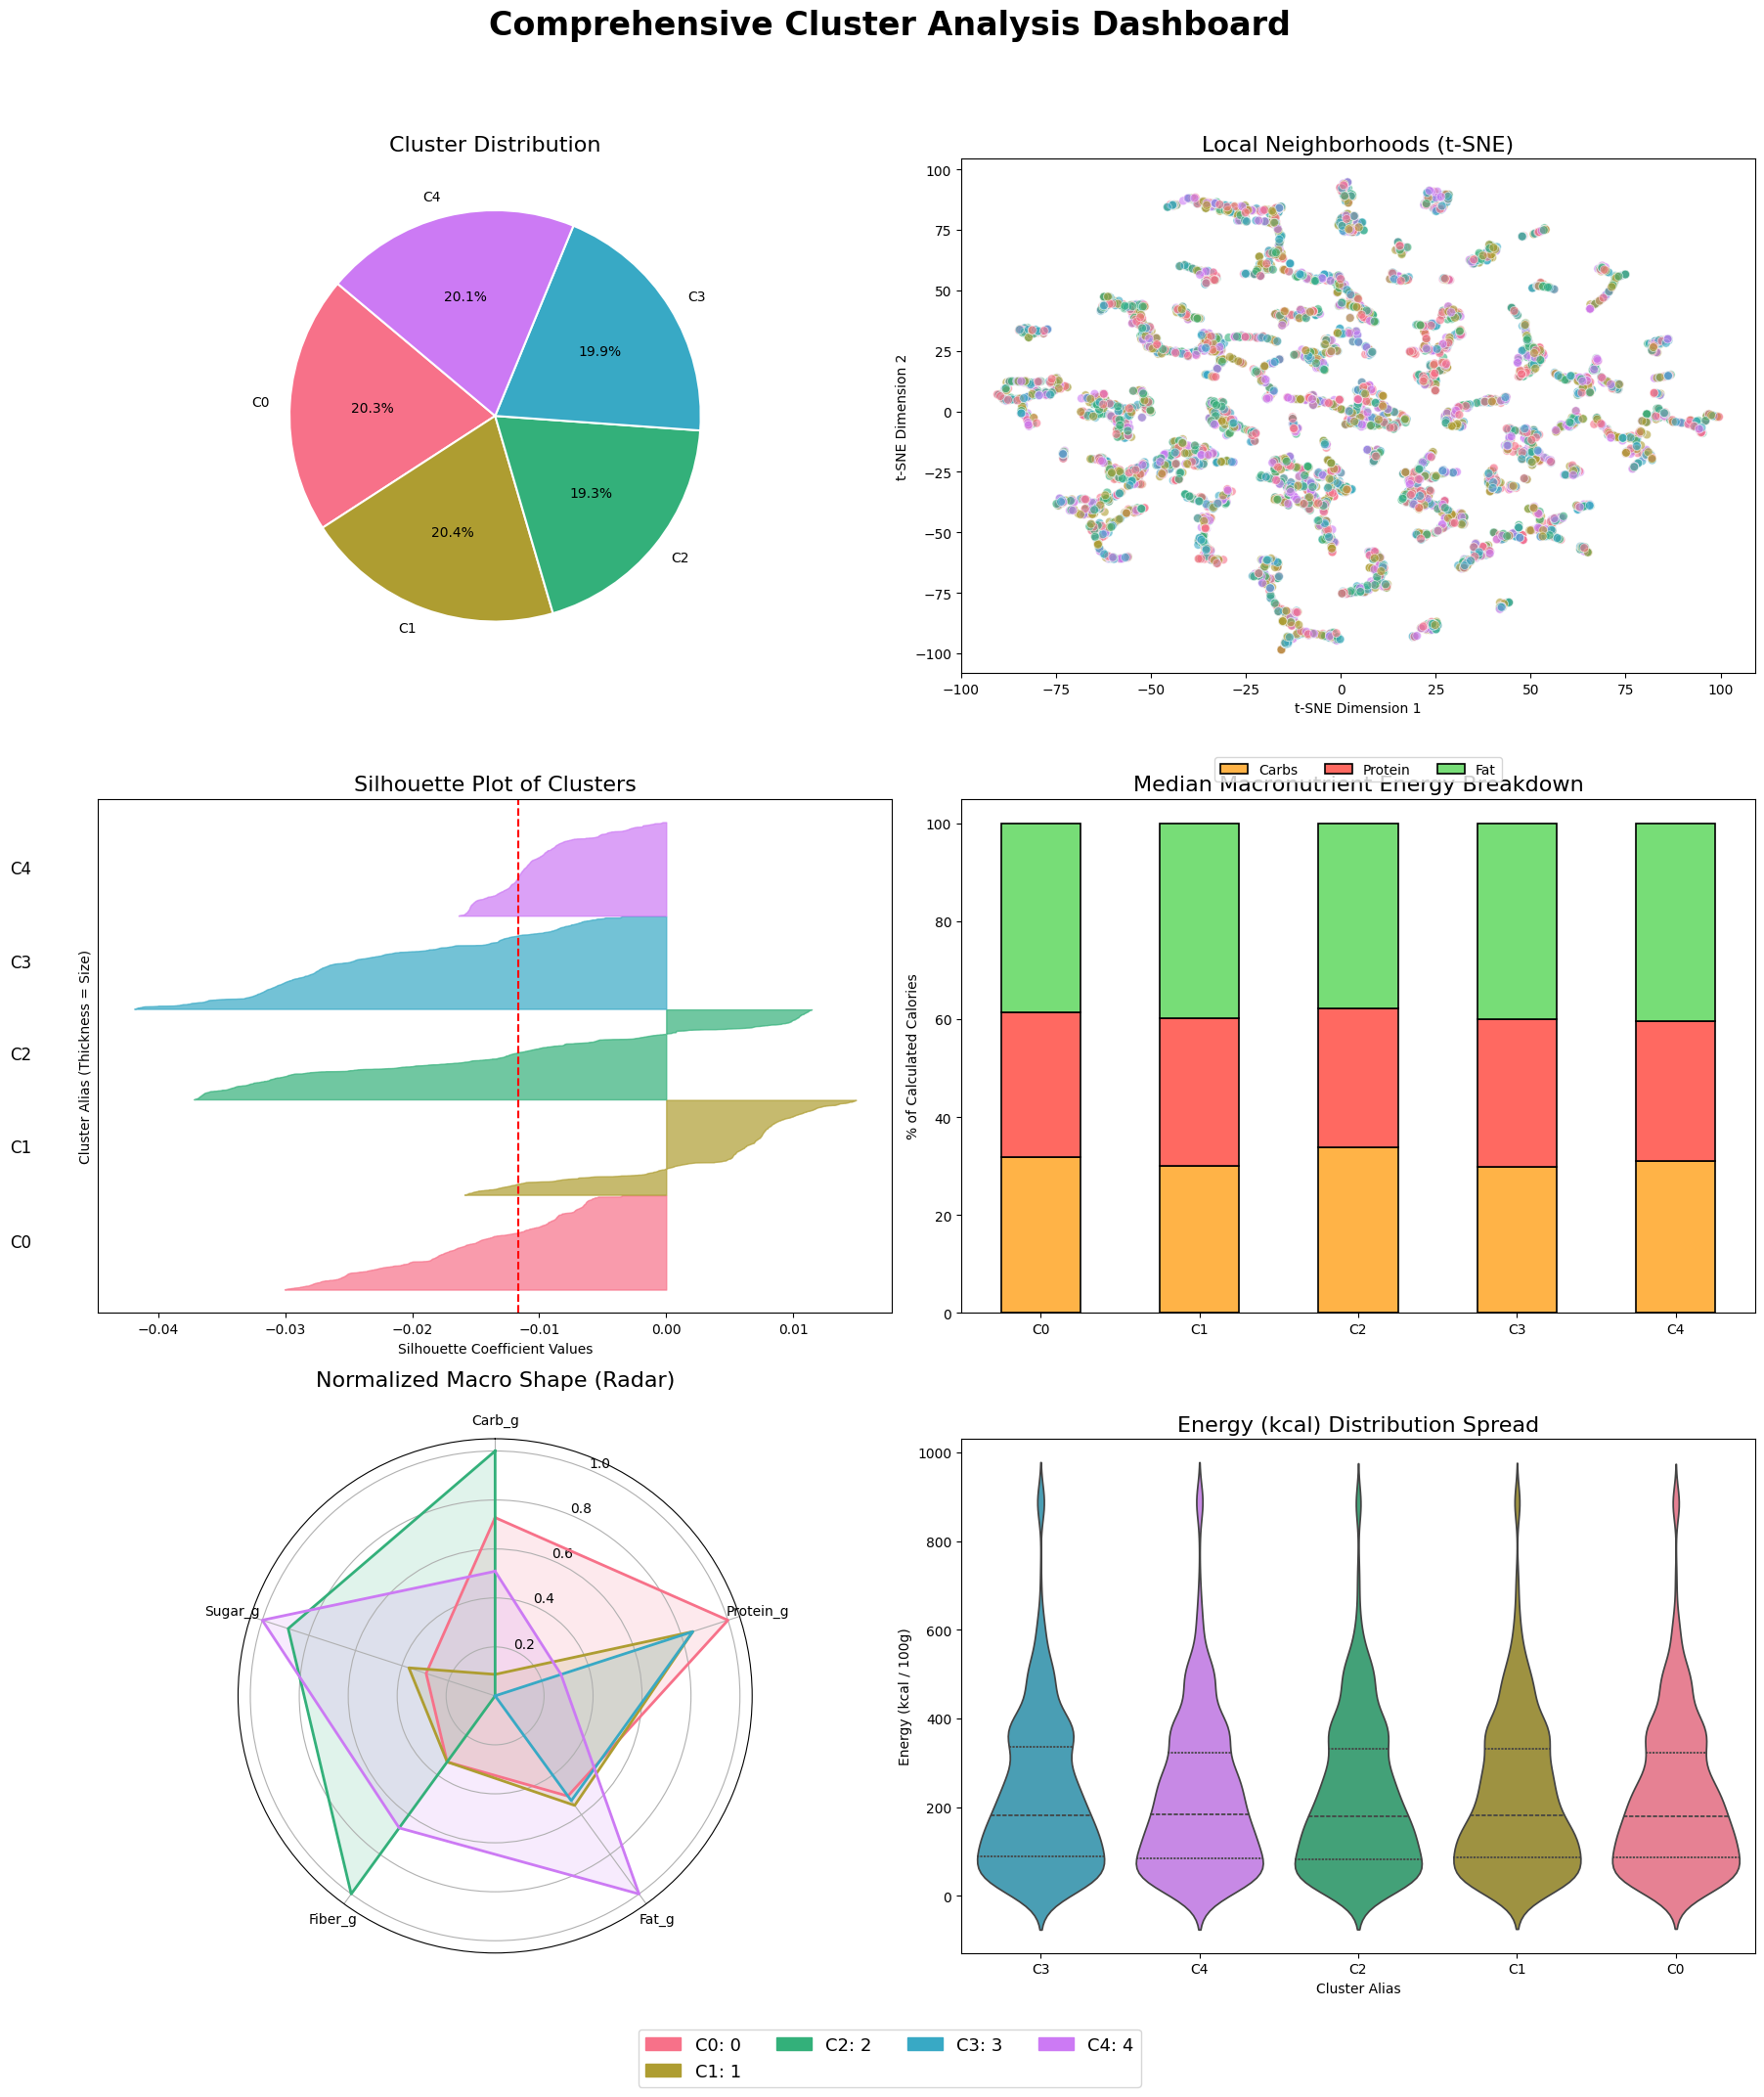

In [13]:
evaluate_and_visualize_clusters(X_eng, X_umap, random_labels)

After visualizing the dataset using t-SNE, the resulting embeddings revealed several visually distinct and well-structured groupings within the nutritional data. These projections suggest that meaningful underlying patterns exist among foods based on their nutrient compositions, indicating strong potential for successful clustering using density-based methods such as DBSCAN or HDBSCAN. The visual separation observed in the lower-dimensional representations provides a promising foundation for identifying natural food clusters and nutritional profiles.

### Training DBSCAN


In [14]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from umap import UMAP

RANDOM_STATE = 43
SEARCH_SIZE = X_umap.shape[0]  # Use all samples for search if dataset is small
VIS_SIZE = X_umap.shape[0]  # Use all samples for visualization if dataset is small    


search_size = min(SEARCH_SIZE, len(X_umap))
rng_search = np.random.RandomState(RANDOM_STATE)
search_positions = rng_search.choice(len(X_umap), size=search_size, replace=False)

search_X_umap = X_umap[search_positions] # random samples

search_X_eval = X_preprocessed.values[search_positions] 

# DBSCAN GRID SEARCH
param_grid = {
    "eps": [1.0,1.2,1.5,2.0],
    "min_samples": [15, 20,22, 25] 
}

results = []
best_score = -1
best_params = None

print("\nRunning DBSCAN parameter sweep...")
for eps in param_grid["eps"]:
    for min_samples in param_grid["min_samples"]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(search_X_umap)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        score = 0
        if n_clusters > 1:
            # Evaluating on original 30D space for accuracy

            non_noise = labels != -1

            filtered_labels = labels[non_noise]

            if len(set(filtered_labels)) > 1:

                score = silhouette_score(
                    search_X_umap[non_noise],
                    filtered_labels
                )
            results.append({"eps": eps, "min_samples": min_samples, "n_clusters": n_clusters, "score": score})
            
            if score > best_score:
                best_score = score
                best_params = {"eps": eps, "min_samples": min_samples}
                best_labels = labels

results_df = pd.DataFrame(results).sort_values("score", ascending=False)
print("\nTOP CONFIGURATIONS:")
print(results_df.head(5).to_string(index=False))

print(f"\nBest Configuration: {best_params}")


Running DBSCAN parameter sweep...

TOP CONFIGURATIONS:
 eps  min_samples  n_clusters    score
 2.0           25           4 0.472136
 2.0           22           4 0.472136
 2.0           20           4 0.472136
 2.0           15           4 0.472136
 1.5           25           4 0.472136

Best Configuration: {'eps': 1.5, 'min_samples': 15}


CLUSTER SIZE STATISTICS
        Alias  Size (Rows)  Percentage (%)
Cluster                                   
0          C0         5878           64.20
1          C1         3007           32.84
2          C2          152            1.66
3          C3          119            1.30




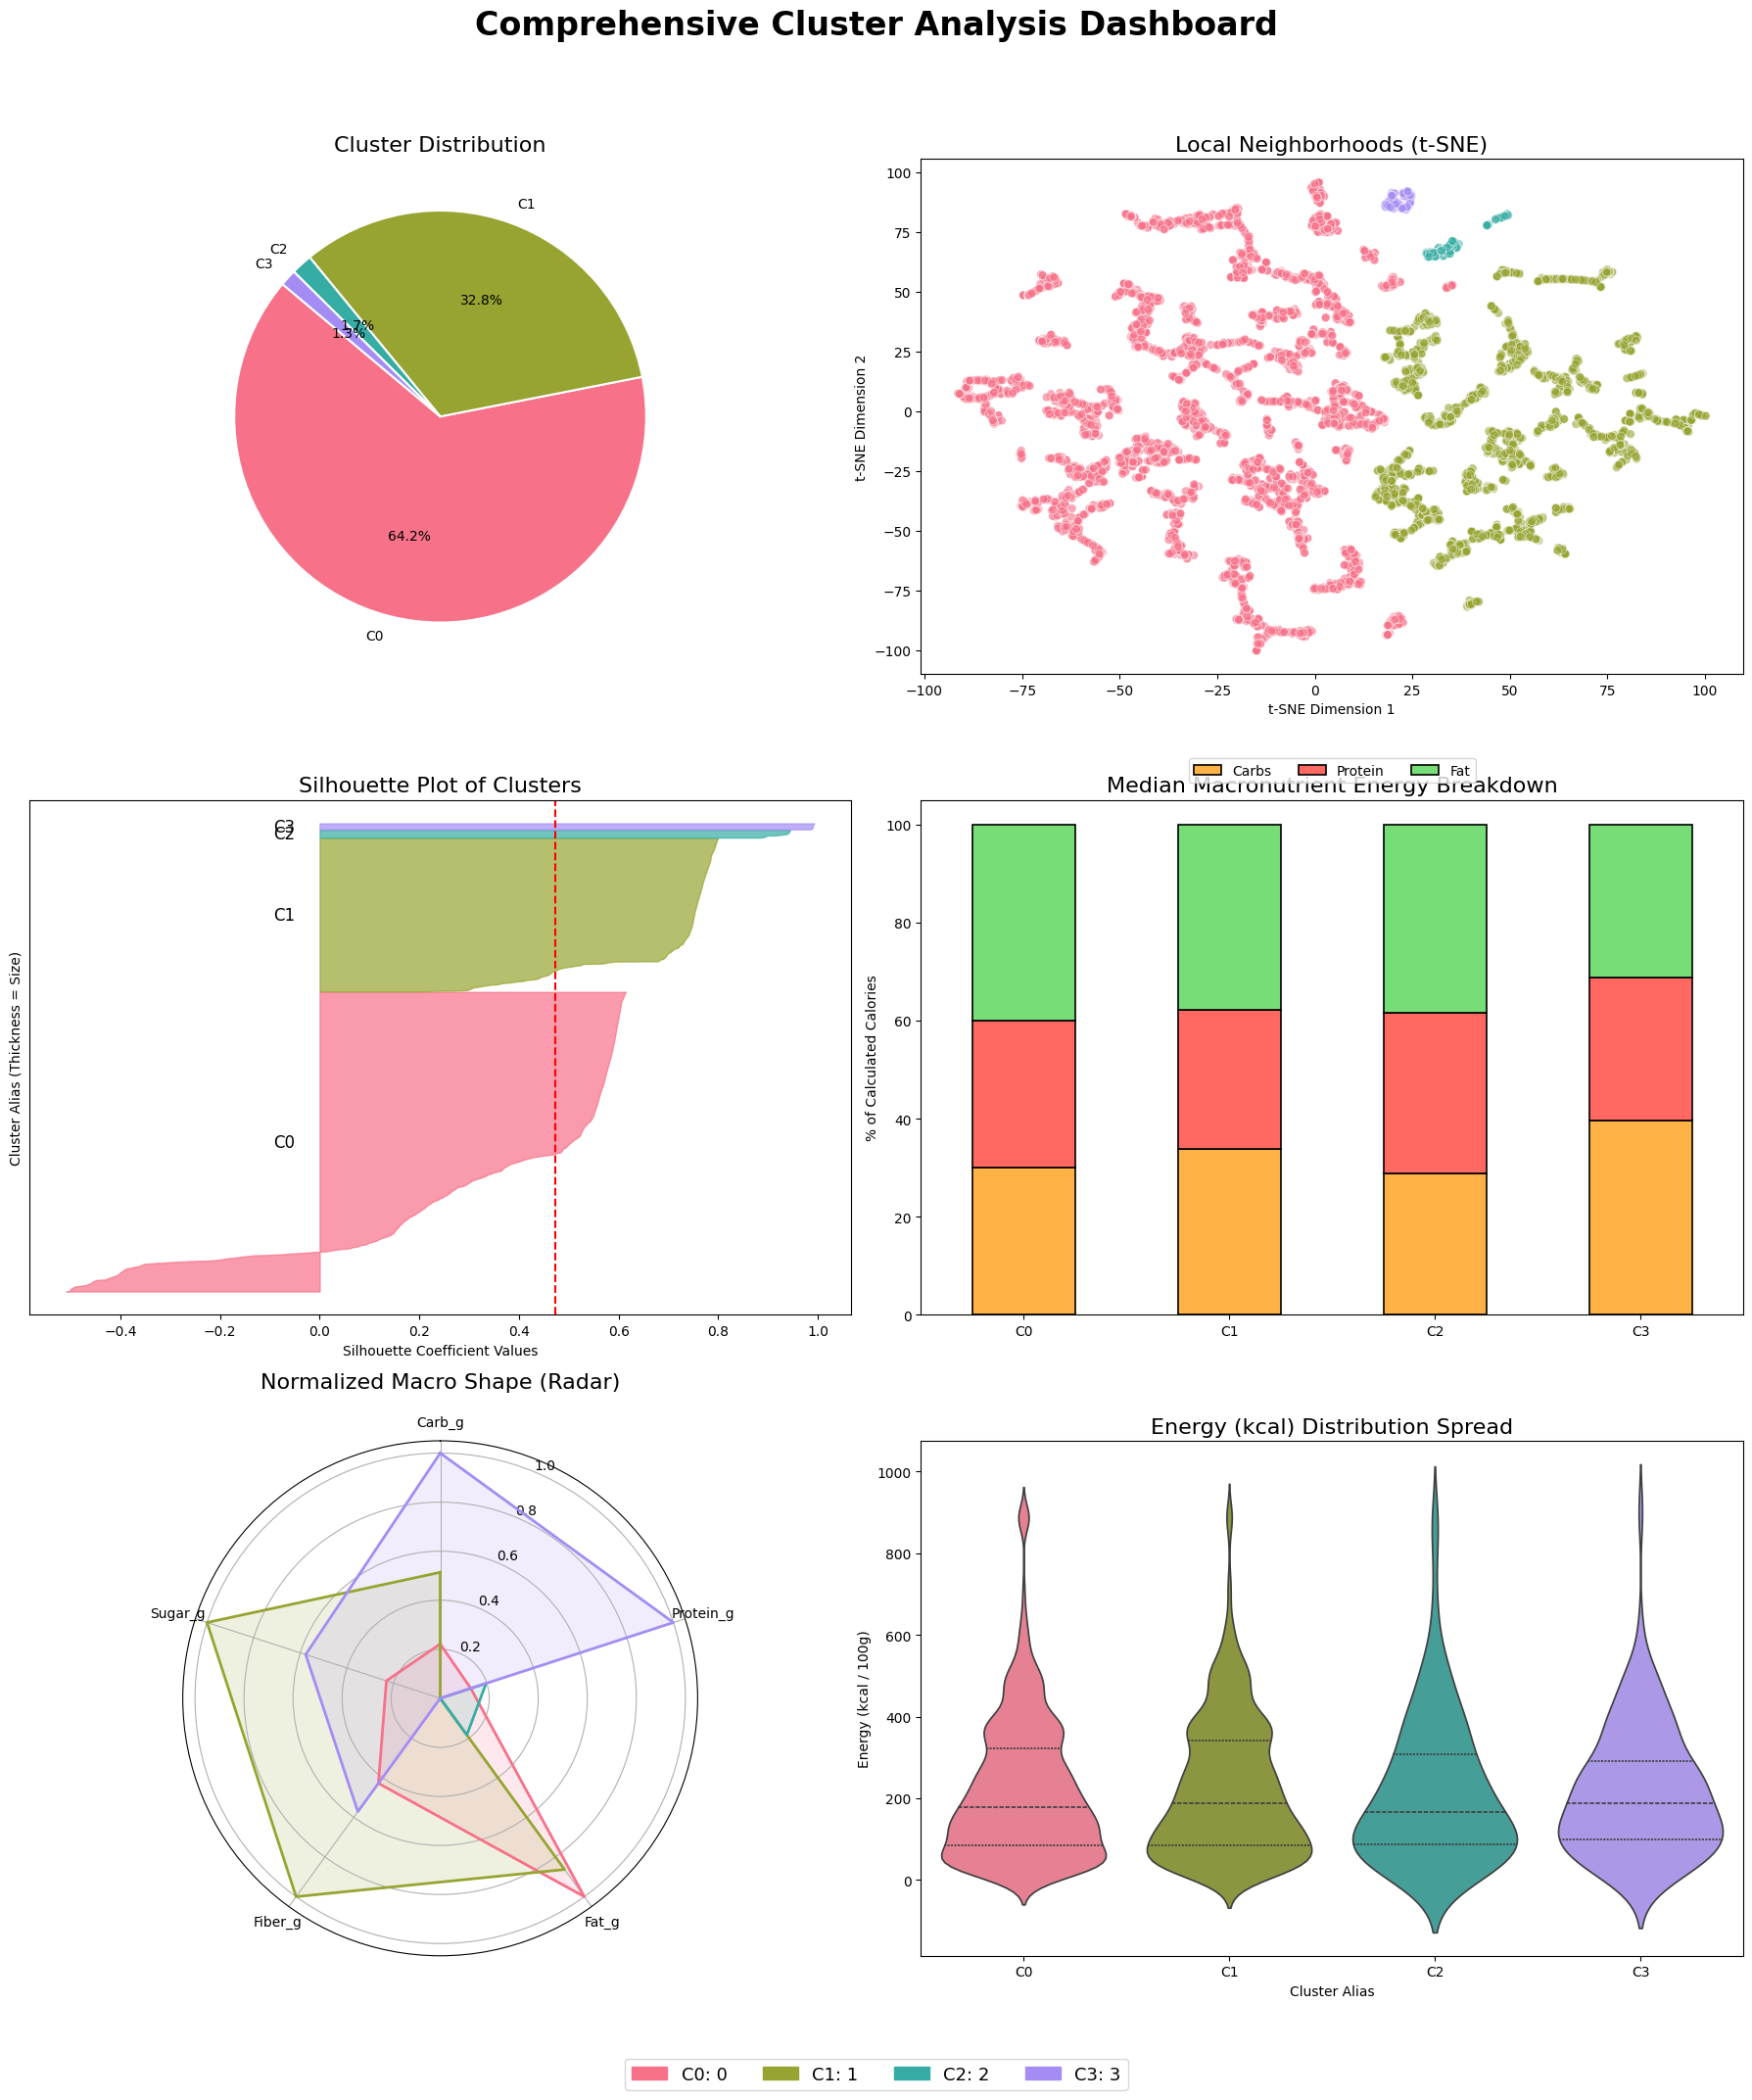

In [15]:
evaluate_and_visualize_clusters(X_eng, search_X_umap, best_labels)

Despite exploring various parameter combinations through techniques like grid search, the DBSCAN algorithm frequently produces unsatisfactory clusters. Even though the best result was scored at pleasing 0.459761, the visualized result is underwhelming and not accurate, as 4 clusters is not sufficient.

Higher score than 0.459761 was achieved by increasing the eps metric, but the result was vague - with only few large clusters.

In this section, the algorithm HDBSCAN will be utilised on the same dataset, to study its results and later compare them to DBSCAN.

In [16]:
from hdbscan import HDBSCAN

# 1. Define the grid from your source [9]
param_grid = {
    "min_cluster_size": [10,12,15,20 ],
    "min_samples": [ 25,30, 35],
    "cluster_selection_epsilon": [0.1,0.15,0.2,0.5],
}

search_size = min(SEARCH_SIZE, len(X_umap))
rng_search = np.random.RandomState(RANDOM_STATE)
search_positions = rng_search.choice(len(X_umap), size=search_size, replace=False)

search_X_umap = X_umap[search_positions] # random samples

search_X_eval = X_log1p_scaled.values[search_positions] 
results = []
best_score = -1
best_params = None


# 2. Run the sweep on your 10D UMAP search sample [10]
# Assuming 'search_X' is your UMAP-reduced data
for mcs in param_grid["min_cluster_size"]:
    for ms in param_grid["min_samples"]:
        for cse in param_grid["cluster_selection_epsilon"]:
            model = HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                cluster_selection_epsilon=cse,
                cluster_selection_method="eom"
            )
            labels = model.fit_predict(search_X_umap)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
            score = 0
            if n_clusters > 1:
                # Evaluating on original 30D space for accuracy

                if len(set(filtered_labels)) > 1:

                    score = silhouette_score(
                        search_X_umap,
                        labels
                    )
                results.append({"min_cluster_size": mcs, "min_samples": ms, "cluster_selection_epsilon": cse, "n_clusters": n_clusters, "score": score})
                
                if score > best_score:
                    best_score = score
                    best_params = {"min_cluster_size": mcs, "min_samples": ms, "cluster_selection_epsilon": cse}
                    best_labels = labels

results_df = pd.DataFrame(results).sort_values("score", ascending=False)
print("\nTOP CONFIGURATIONS:")
print(results_df.head(5).to_string(index=False))

print(f"\nBest Configuration: {best_params}")


TOP CONFIGURATIONS:
 min_cluster_size  min_samples  cluster_selection_epsilon  n_clusters    score
               20           30                       0.20          37 0.343767
               20           30                       0.10          39 0.337640
               20           30                       0.15          39 0.337640
               15           30                       0.20          42 0.305524
               15           30                       0.15          45 0.296715

Best Configuration: {'min_cluster_size': 20, 'min_samples': 30, 'cluster_selection_epsilon': 0.2}


CLUSTER SIZE STATISTICS
        Alias  Size (Rows)  Percentage (%)
Cluster                                   
-1         C0         1192           13.02
 0         C1          119            1.30
 1         C2          383            4.18
 2         C3           43            0.47
 3         C4          212            2.32
 4         C5          177            1.93
 5         C6           98            1.07
 6         C7           42            0.46
 7         C8          286            3.12
 8         C9           62            0.68
 9        C10         2176           23.77
 10       C11          205            2.24
 11       C12           34            0.37
 12       C13           42            0.46
 13       C14          508            5.55
 14       C15          379            4.14
 15       C16           77            0.84
 16       C17           34            0.37
 17       C18           99            1.08
 18       C19          355            3.88
 19       C20           56    

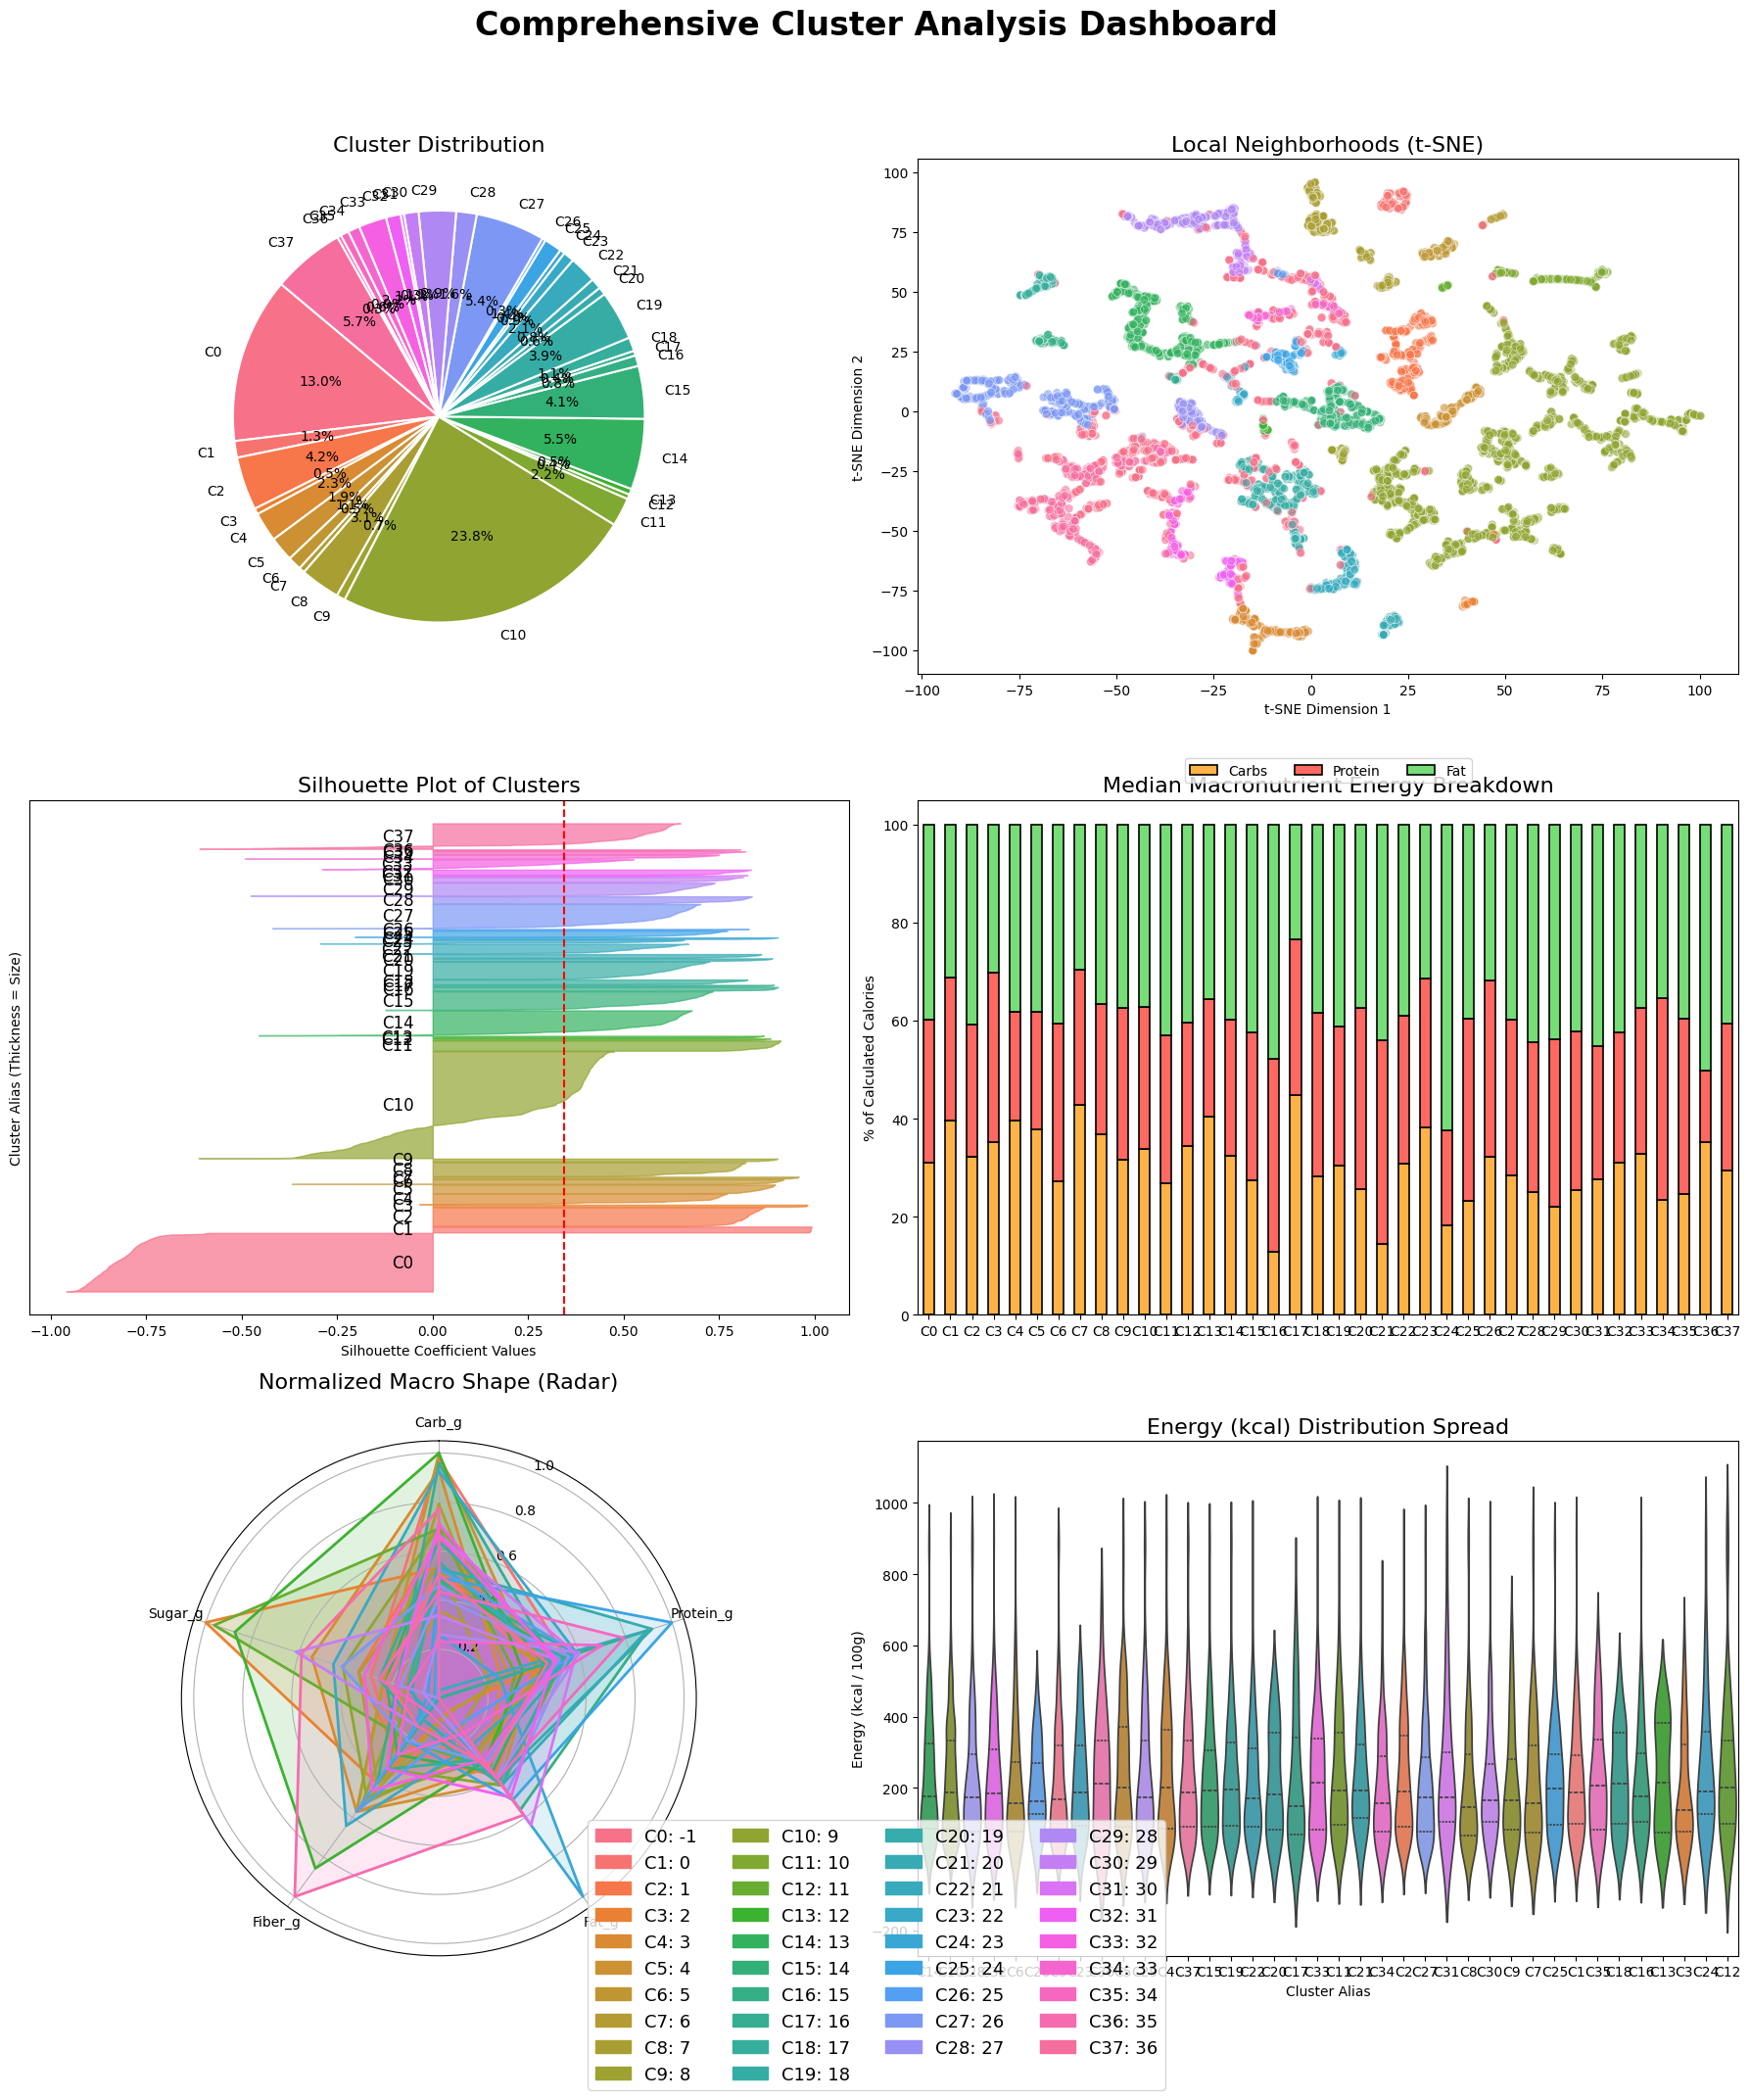

In [17]:
evaluate_and_visualize_clusters(X_eng, search_X_umap, best_labels)

As we can see, the HDBSCAN yielded very different results as DBSCAN.

Finding the right combination of parameters was challenging, since increasing the cluster_selection_epsilon or min_cluster_size can artificially inflate silhouette scores by forcing the algorithm to merge smaller density peaks into a few massive groupings. While this "optimization" might suggest a better result, it often leads to fewer clusters that are "visibly incorrect".

Similarly, adjusting min_samples to higher values can make the model overly conservative, pushing significant portions of the data into the noise category to satisfy the algorithm's goal of "not being wrong". This results in an "underwhelming" clustering that ignores the natural gaps and "manifold boundaries" visible in t-SNE embeddings, effectively trading the recovery of true data structure for a higher, but ultimately misleading, mathematical validation score.

### Comparison for HDBSCAN

Generating t-SNE embedding...


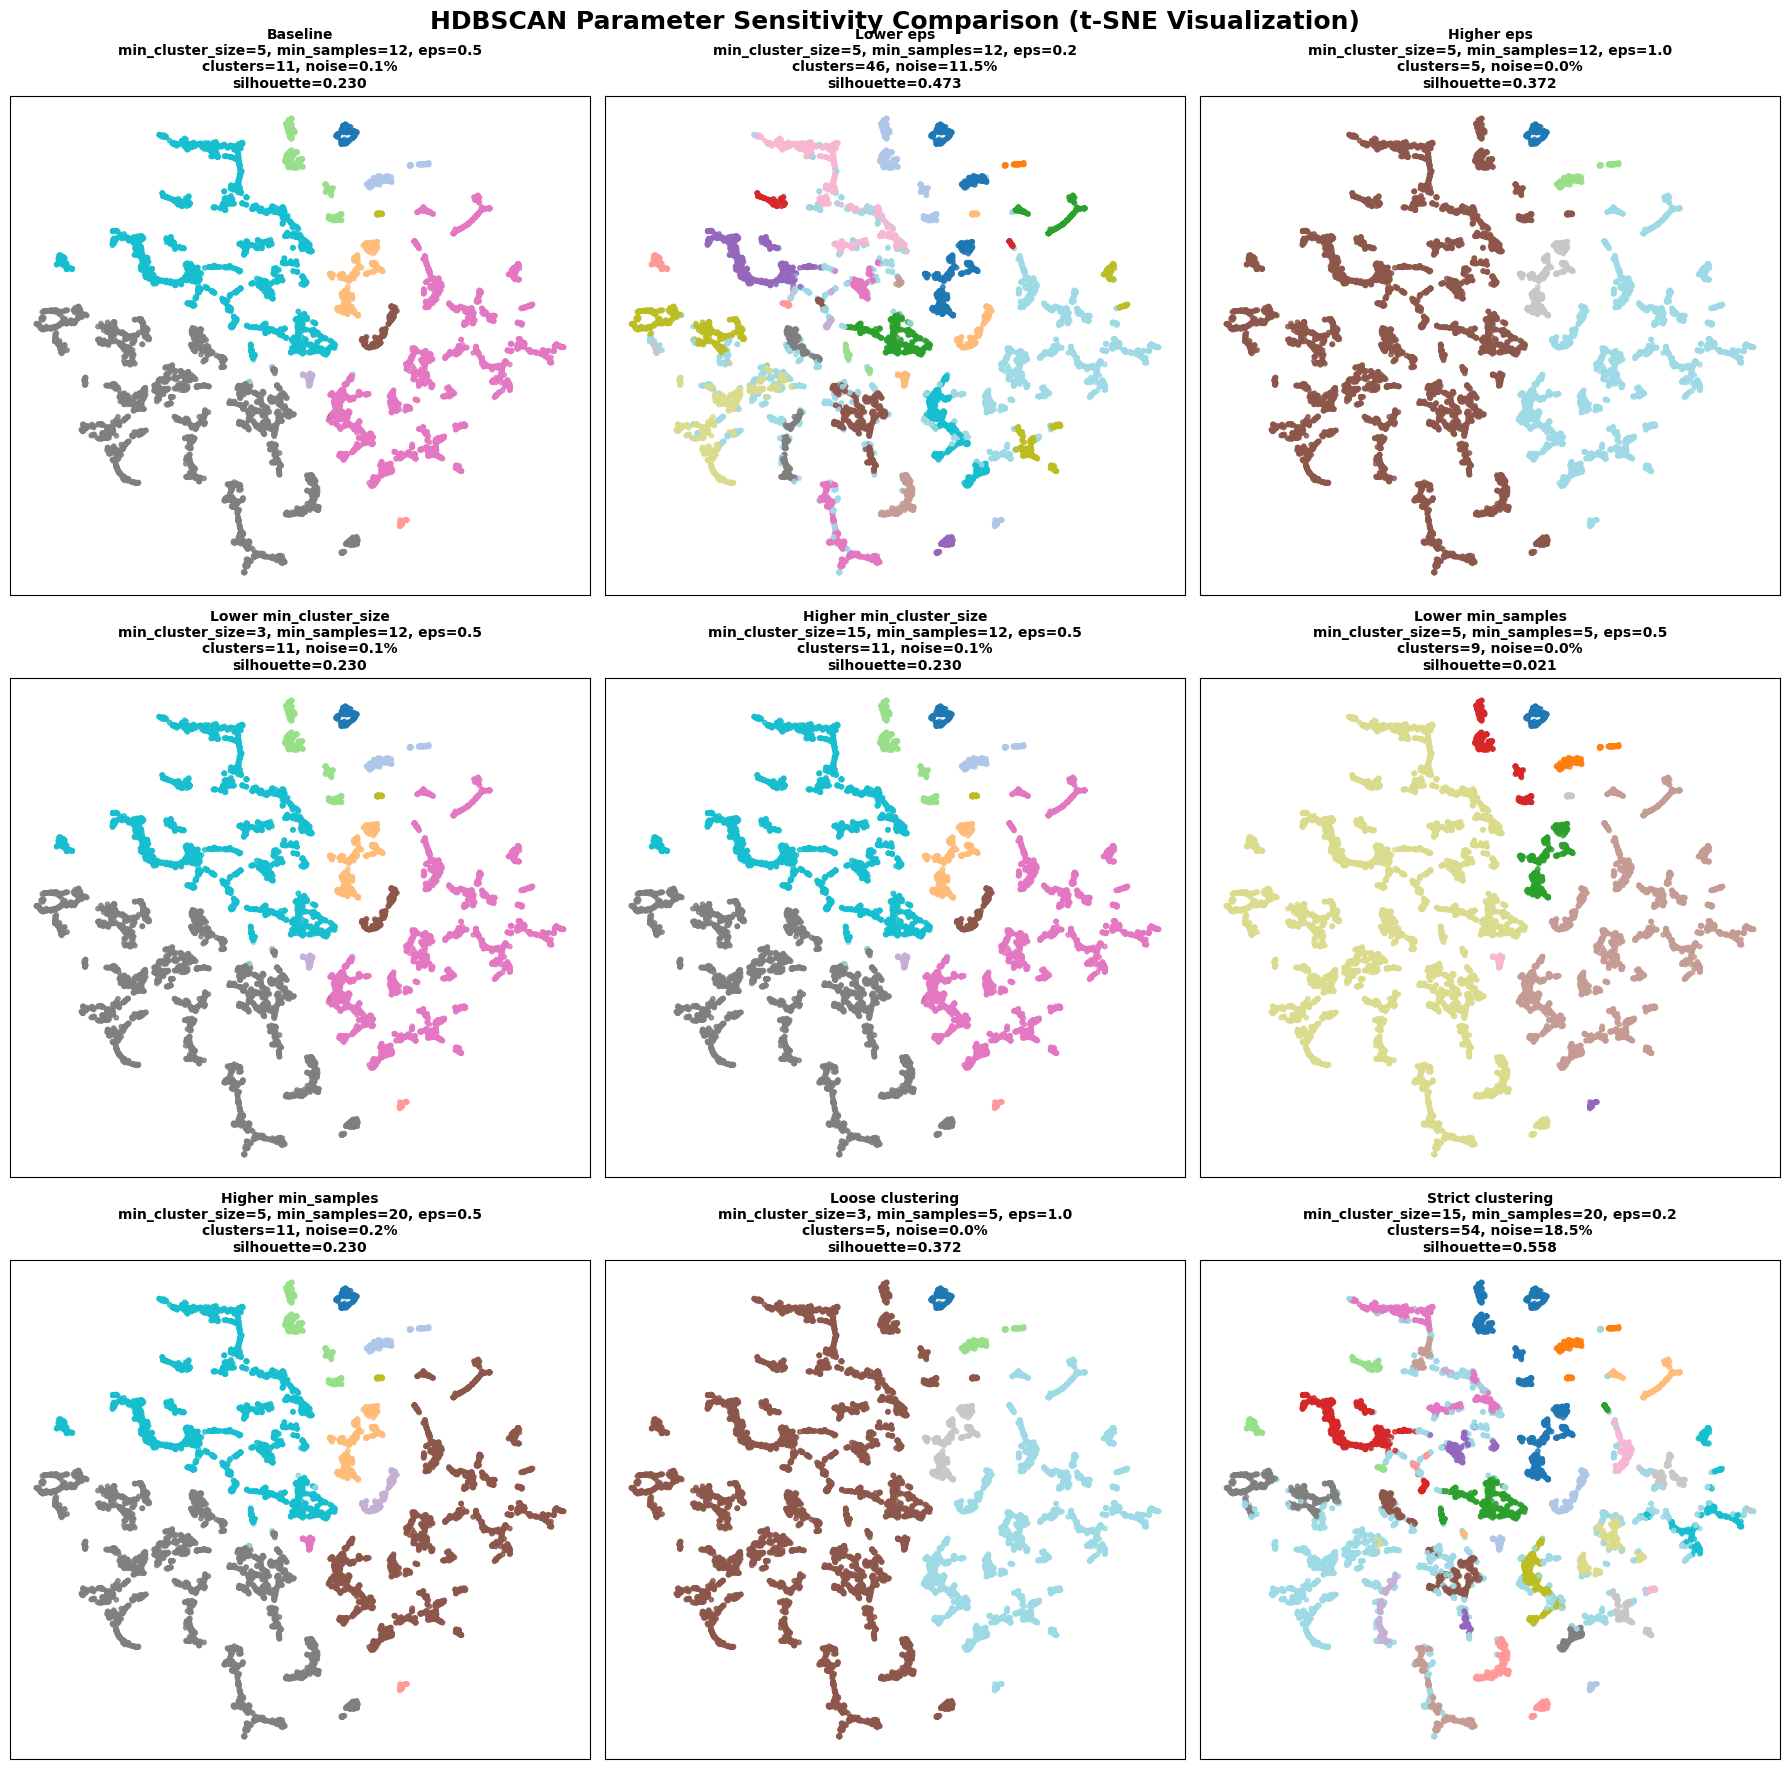

In [18]:
from hdbscan import HDBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import numpy as np

configs = [
    # BASELINE
    {
        "title": "Baseline",
        "min_cluster_size": 5,
        "min_samples": 12,
        "eps": 0.5
    },

    # EPSILON VARIATIONS
    {
        "title": "Lower eps",
        "min_cluster_size": 5,
        "min_samples": 12,
        "eps": 0.2
    },

    {
        "title": "Higher eps",
        "min_cluster_size": 5,
        "min_samples": 12,
        "eps": 1.0
    },

    # MIN CLUSTER SIZE VARIATIONS
    {
        "title": "Lower min_cluster_size",
        "min_cluster_size": 3,
        "min_samples": 12,
        "eps": 0.5
    },

    {
        "title": "Higher min_cluster_size",
        "min_cluster_size": 15,
        "min_samples": 12,
        "eps": 0.5
    },

    # MIN SAMPLES VARIATIONS
    {
        "title": "Lower min_samples",
        "min_cluster_size": 5,
        "min_samples": 5,
        "eps": 0.5
    },

    {
        "title": "Higher min_samples",
        "min_cluster_size": 5,
        "min_samples": 20,
        "eps": 0.5
    },

    # COMBINED VARIATIONS
    {
        "title": "Loose clustering",
        "min_cluster_size": 3,
        "min_samples": 5,
        "eps": 1.0
    },

    {
        "title": "Strict clustering",
        "min_cluster_size": 15,
        "min_samples": 20,
        "eps": 0.2
    }
]

print("Generating t-SNE embedding...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

embedding = tsne.fit_transform(X_umap)


fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 18)
)

axes = axes.flatten()


for idx, config in enumerate(configs):

    model = HDBSCAN(
        min_cluster_size=config["min_cluster_size"],
        min_samples=config["min_samples"],
        cluster_selection_epsilon=config["eps"],
        cluster_selection_method="eom"
    )
    labels = model.fit_predict(X_umap)


    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = np.mean(labels == -1) * 100

    sil_score = np.nan
    if n_clusters > 1:

        non_noise = labels != -1
        filtered_labels = labels[non_noise]

        if len(set(filtered_labels)) > 1:

            sil_score = silhouette_score(
                X_umap[non_noise],
                filtered_labels
            )


    display_labels = labels.copy().astype(int)
    if (display_labels == -1).any():

        display_labels[
            display_labels == -1
        ] = display_labels.max() + 1


    ax = axes[idx]
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=display_labels,
        cmap="tab20",
        s=10,
        alpha=0.8
    )

    sil_text = (
        f"{sil_score:.3f}"
        if not np.isnan(sil_score)
        else "NaN"
    )

    ax.set_title(
        (
            f"{config['title']}\n"
            f"min_cluster_size={config['min_cluster_size']}, "
            f"min_samples={config['min_samples']}, "
            f"eps={config['eps']}\n"
            f"clusters={n_clusters}, "
            f"noise={noise_pct:.1f}%\n"
            f"silhouette={sil_text}"
        ),
        fontsize=10,
        fontweight="bold"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.2)

plt.suptitle(
    "HDBSCAN Parameter Sensitivity Comparison (t-SNE Visualization)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

We observe that even small changes in hyperparameters can lead to substantially different clustering results. This makes it difficult to identify a stable and clearly optimal configuration. While the silhouette score tends to increase with a larger number of clusters, solutions with 50+ clusters are not practically useful for interpretation, as they over-segment the data into overly fine-grained groups.

On the other hand, when the number of clusters is constrained to around 10, the t-SNE visualizations show that a large proportion of the data collapses into one dominant cluster, with only a few smaller clusters separating out. This indicates under-segmentation, where meaningful structure is not fully captured.

Overall, there is a clear trade-off between cluster granularity and interpretability, with no single configuration providing both strong separation and meaningful, human-interpretable groupings.

Lets evaluate the best configuration of HDBSCAN:

In [19]:
# Reattach origianl dataframe
df_results = X_eng.copy()

best_model = model = HDBSCAN(
        min_cluster_size=best_params["min_cluster_size"],
        min_samples=best_params["min_samples"],
        cluster_selection_epsilon=best_params["cluster_selection_epsilon"],
        cluster_selection_method="eom"
    )


df_results['Cluster'] = best_labels
df_results['Descrip'] = df.loc[df_results.index, 'Descrip']
df_results['NDB_No'] = df.loc[df_results.index, 'NDB_No']

# Reorder the columns
cols = ['NDB_No', 'Descrip', 'Cluster'] + [c for c in df_results.columns if c not in ['NDB_No', 'Descrip', 'Cluster']]
df_results = df_results[cols]

# Print 10 random foods from each cluster:
for i in range(df_results['Cluster'].nunique()):
    print("\n=========================================")
    print(f"CLUSTER {i} SAMPLES")
    print("=========================================")

    # Min in case a cluster is tiny
    sample_size = min(10, len(df_results[df_results['Cluster'] == i]))
    samples = df_results[df_results['Cluster'] == i]['Descrip'].sample(sample_size, random_state=42)
    
    for food in samples.values:
        print(f"- {food}")


CLUSTER 0 SAMPLES
- pie choc mousse prep from mix no-bake type
- lamb aus imp frsh shldr blade lnfat 18"fat raw
- ice creams french vanilla soft-serve
- alcoholic bev beer lt lo carb
- beverages energy drk rockstar sugar free
- fast foods griddle cake sndwch egg chs  sausage
- collards frz chopd ckd bld drnd wosalt
- beverages choc pdr no sugar added
- chicken roasting meat only ckd rstd
- chicken broilers or fryers back meat only raw

CLUSTER 1 SAMPLES
- beef rnd eye of rnd steak bnless ln  ft 0" fat all grds raw
- rice white medium-grain enr ckd
- milk dry nonfat inst wo added vit a  vitamin d
- doughnuts cake-type pln sugared or glazed
- beef rib whl (ribs 6-12) lnfat 18"fat all grds raw
- campbell's healthy request homestyle chick noodle soup cond
- peanuts all types ckd bld wsalt
- babyfood dssrt cherry vanilla pudd str
- sunflower sd flr part defatted
- fast foods submarine sndwch bacon lettuce  tomato wht brd

CLUSTER 2 SAMPLES
- babyfood  dinner  chick stew  todd
- drumstick p

Even after letting the algorithm separate data into 55 clusters, most of the clusters do not make sense. HDBSCAN is partially effective on this dataset, but it does not produce clean semantic food categories. Instead, it identifies density-based nutritional similarity regions, which often mix semantically different foods that share similar macro- or micro-nutrient profiles. This is especially visible in clusters combining snacks, grains, and processed foods.

Given the structure of the dataset (high-dimensional nutritional features with strong correlation between variables like fat, calories, and carbs), HDBSCAN is appropriate for discovering hidden structure and outliers, but *not* ideal for producing human-interpretable categorical groups.

| Cluster | Main Theme                              | Representative Foods                              | Why It Works Well                                          |
| ------- | --------------------------------------- | ------------------------------------------------- | ---------------------------------------------------------- |
| 8       | Fast food & high-fat processed meals    | Salisbury steak, sausage, whiskey sour, palm oil  | Strong grouping of calorie-dense processed foods and fats. |
| 12      | Refined carbohydrates & processed foods | Pizza, crackers, potatoes, cereals                | Clear separation around processed carb-heavy foods.        |
| 13      | Lean meats & savory protein foods       | Chicken breast, ham, crayfish, gravy              | Consistent high-protein savory products.                   |
| 16      | Bakery & snack foods                    | Pie crust, tortilla chips, pretzels, coffee mixes | Well-defined snack/refined grain cluster.                  |
| 17      | Red meat & animal protein               | Beef ribs, turkey, fried chicken                  | Strong animal-protein-focused cluster.                     |
| 19      | Protein-rich prepared foods             | Chicken, sausage, egg yolk, mozzarella            | Cohesive processed protein/meat category.                  |
| 24      | Sauces, syrups & prepared meals         | Corn syrup, buffalo sauce, hash browns            | Distinct condiment and processed-food profile.             |
| 27      | Savory cooked foods & nuts              | Turkey, pasta sauce, tortillas, almonds           | Relatively coherent prepared-meal cluster.                 |
| 31      | Oils, sauces & cooked proteins          | Margarine, beef ribeye, pasta sauce               | Clear high-fat and prepared-food orientation.              |
| 54      | Fast food & salty processed foods       | Cheeseburgers, tartar sauce, plantain chips       | Strong clustering of processed restaurant-style foods.     |


## KMeans (Tomko)
I chose the K-Means algorithm, an unsupervised machine learning technique designed for exploratory data analysis and clustering. The goal of this model is to partition the available dataset into a predefined number of clusters ($k$) such that the samples within a single cluster are as similar to each other as possible, while being as distinct as possible from samples in other clusters. In our case, similarity is measured using Euclidean distance within an n-dimensional space of nutritional features.

During the learning (training) phase, the model first initializes $k$ initial cluster centers (centroids) using the optimized k-means++ method. It then iteratively alternates between two steps: first, it assigns each data point to the nearest centroid, and second, it recalculates the coordinates of each centroid as the arithmetic mean of all the data points currently assigned to it. This process of minimizing the within-cluster variance is repeated until the positions of the centroids stop changing (i.e., the model converges). The result of the training is a set of $k$ centroids representing the typical profile of a given group (e.g., the mathematical "ideal" of a vegetable or a sweet), along with an assignment vector that gives each food item in the dataset its specific cluster label.

Evaluating KMeans for different values of k...
k= 4 | Silhouette: 0.2169 | Inertia: 210967
k= 5 | Silhouette: 0.2262 | Inertia: 198594
k= 6 | Silhouette: 0.2557 | Inertia: 180853
k= 7 | Silhouette: 0.2120 | Inertia: 175711
k= 8 | Silhouette: 0.2529 | Inertia: 160328
k= 9 | Silhouette: 0.2136 | Inertia: 155253
k=10 | Silhouette: 0.2150 | Inertia: 153216
k=11 | Silhouette: 0.2253 | Inertia: 149143
k=12 | Silhouette: 0.2133 | Inertia: 144623
k=13 | Silhouette: 0.2138 | Inertia: 140544
k=14 | Silhouette: 0.2027 | Inertia: 137514
k=15 | Silhouette: 0.2075 | Inertia: 134123

Optimal number of clusters (k) based on Silhouette Score: 6


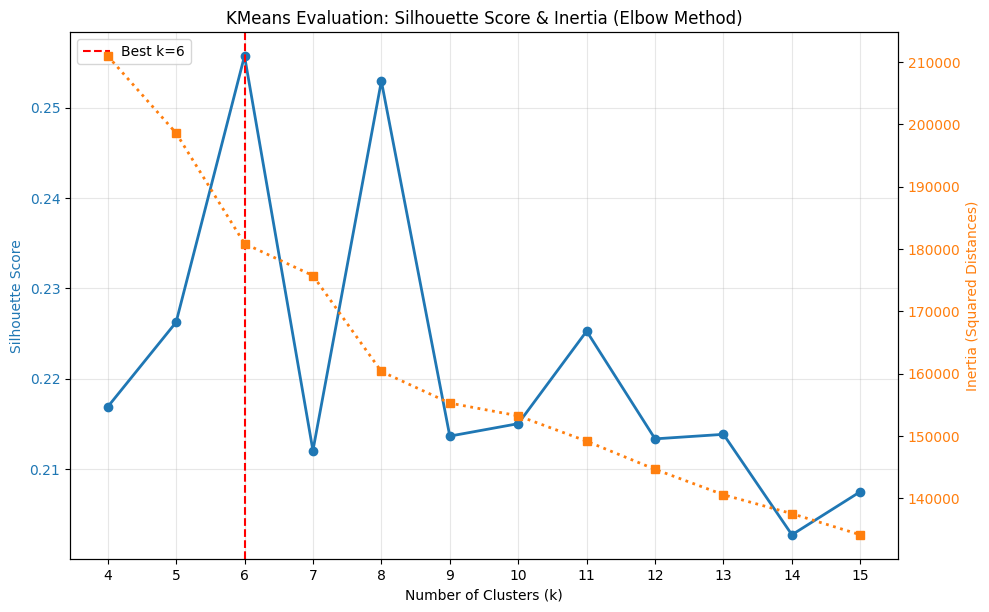

In [20]:
# Define the range of k values to test
k_values = range(4, 16)

silhouette_scores = []
inertias = []
models = {}

print("Evaluating KMeans for different values of k...")

# The elegant for-loop approach
for k in k_values:
    # Initialize and fit the model
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_preprocessed)
    
    # Store the metrics
    silhouette_scores.append(silhouette_score(X_preprocessed, labels))
    inertias.append(kmeans.inertia_)
    
    # Save the model in case this k turns out to be the best
    models[k] = kmeans
    
    print(f"k={k:2d} | Silhouette: {silhouette_scores[-1]:.4f} | Inertia: {inertias[-1]:.0f}")

# Find the best k based on the highest Silhouette Score
best_k = k_values[np.argmax(silhouette_scores)]
best_kmeans_model = models[best_k]

print(f"\nOptimal number of clusters (k) based on Silhouette Score: {best_k}")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Silhouette Score on the left Y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(k_values, silhouette_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')

# Create a secondary Y-axis for Inertia (Elbow Method)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Inertia (Squared Distances)', color=color)  
ax2.plot(k_values, inertias, marker='s', linestyle=':', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Formatting
fig.tight_layout()  
plt.title('KMeans Evaluation: Silhouette Score & Inertia (Elbow Method)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
plt.xticks(k_values)
plt.show()

### Best Model
We visualize the data via dimensionality reduction and compute medians for all features. Furthermore, we also pick a few ingredients from each cluster at random, to get a better picture of what the model learned.

In [21]:
# Reattach origianl dataframe
df_results = X_eng.copy()

df_results['Cluster'] = best_kmeans_model.labels_
df_results['Descrip'] = df.loc[df_results.index, 'Descrip']
df_results['NDB_No'] = df.loc[df_results.index, 'NDB_No']

# Reorder the columns
cols = ['NDB_No', 'Descrip', 'Cluster'] + [c for c in df_results.columns if c not in ['NDB_No', 'Descrip', 'Cluster']]
df_results = df_results[cols]

# Print 10 random foods from each cluster:
for i in range(df_results['Cluster'].nunique()):
    print("\n=========================================")
    print(f"CLUSTER {i} SAMPLES")
    print("=========================================")

    # Min in case a cluster is tiny
    sample_size = min(10, len(df_results[df_results['Cluster'] == i]))
    samples = df_results[df_results['Cluster'] == i]['Descrip'].sample(sample_size, random_state=42)
    
    for food in samples.values:
        print(f"- {food}")


CLUSTER 0 SAMPLES
- kellogg's eggo biscuit scramblers egg  chs
- pepperidge farm goldfish bkd snack crackers cheddar
- pork fresh backfat raw
- cereals rte kashi heart to heart oat flakes  bluebry clstrs
- rice brown parbld dry uncle ben's
- salad drsng mayo imitn soybn
- kellogg's eggo waffles blueberry
- tgi friday's chick fingers from kids' menu
- sauce pesto buitoni pesto w basil rts refr
- frozen novl klondike slim-a-bear no sgr added stickless bar

CLUSTER 1 SAMPLES
- silan
- parcus
- sankata paarai
- gold fish
- kalava
- crab  sea 
- vora
- oyster
- allathi
- kite fish

CLUSTER 2 SAMPLES
- frankfurter bf lo fat
- game meat elk raw
- chicken broilers or fryers thigh meatskn ckd fried flr
- beef aus imp grss-fed loin tenderln stkrst bnless raw
- usda commodity bf patties wvpp frz raw
- beef flank steak ln 0" fat all grds raw
- chicken broilers or fryers back meat only ckd stwd
- beef ground 93 ln meat  7 fat
- trout mixed species raw
- croaker atlantic ckd breadedfried

CLUSTER 3

CLUSTER SIZE STATISTICS
                            Alias  Size (Rows)  Percentage (%)
Cluster                                                       
Fortified Cereals & Carbs      C0          237            2.59
Fruits, Veggies & Beverages    C1         3256           35.56
Grains, Nuts & Seeds           C2          556            6.07
Processed Snacks & Sweets      C3         2304           25.16
Seafood & Organ Meats          C4          114            1.25
Standard Meats & Poultry       C5         2689           29.37




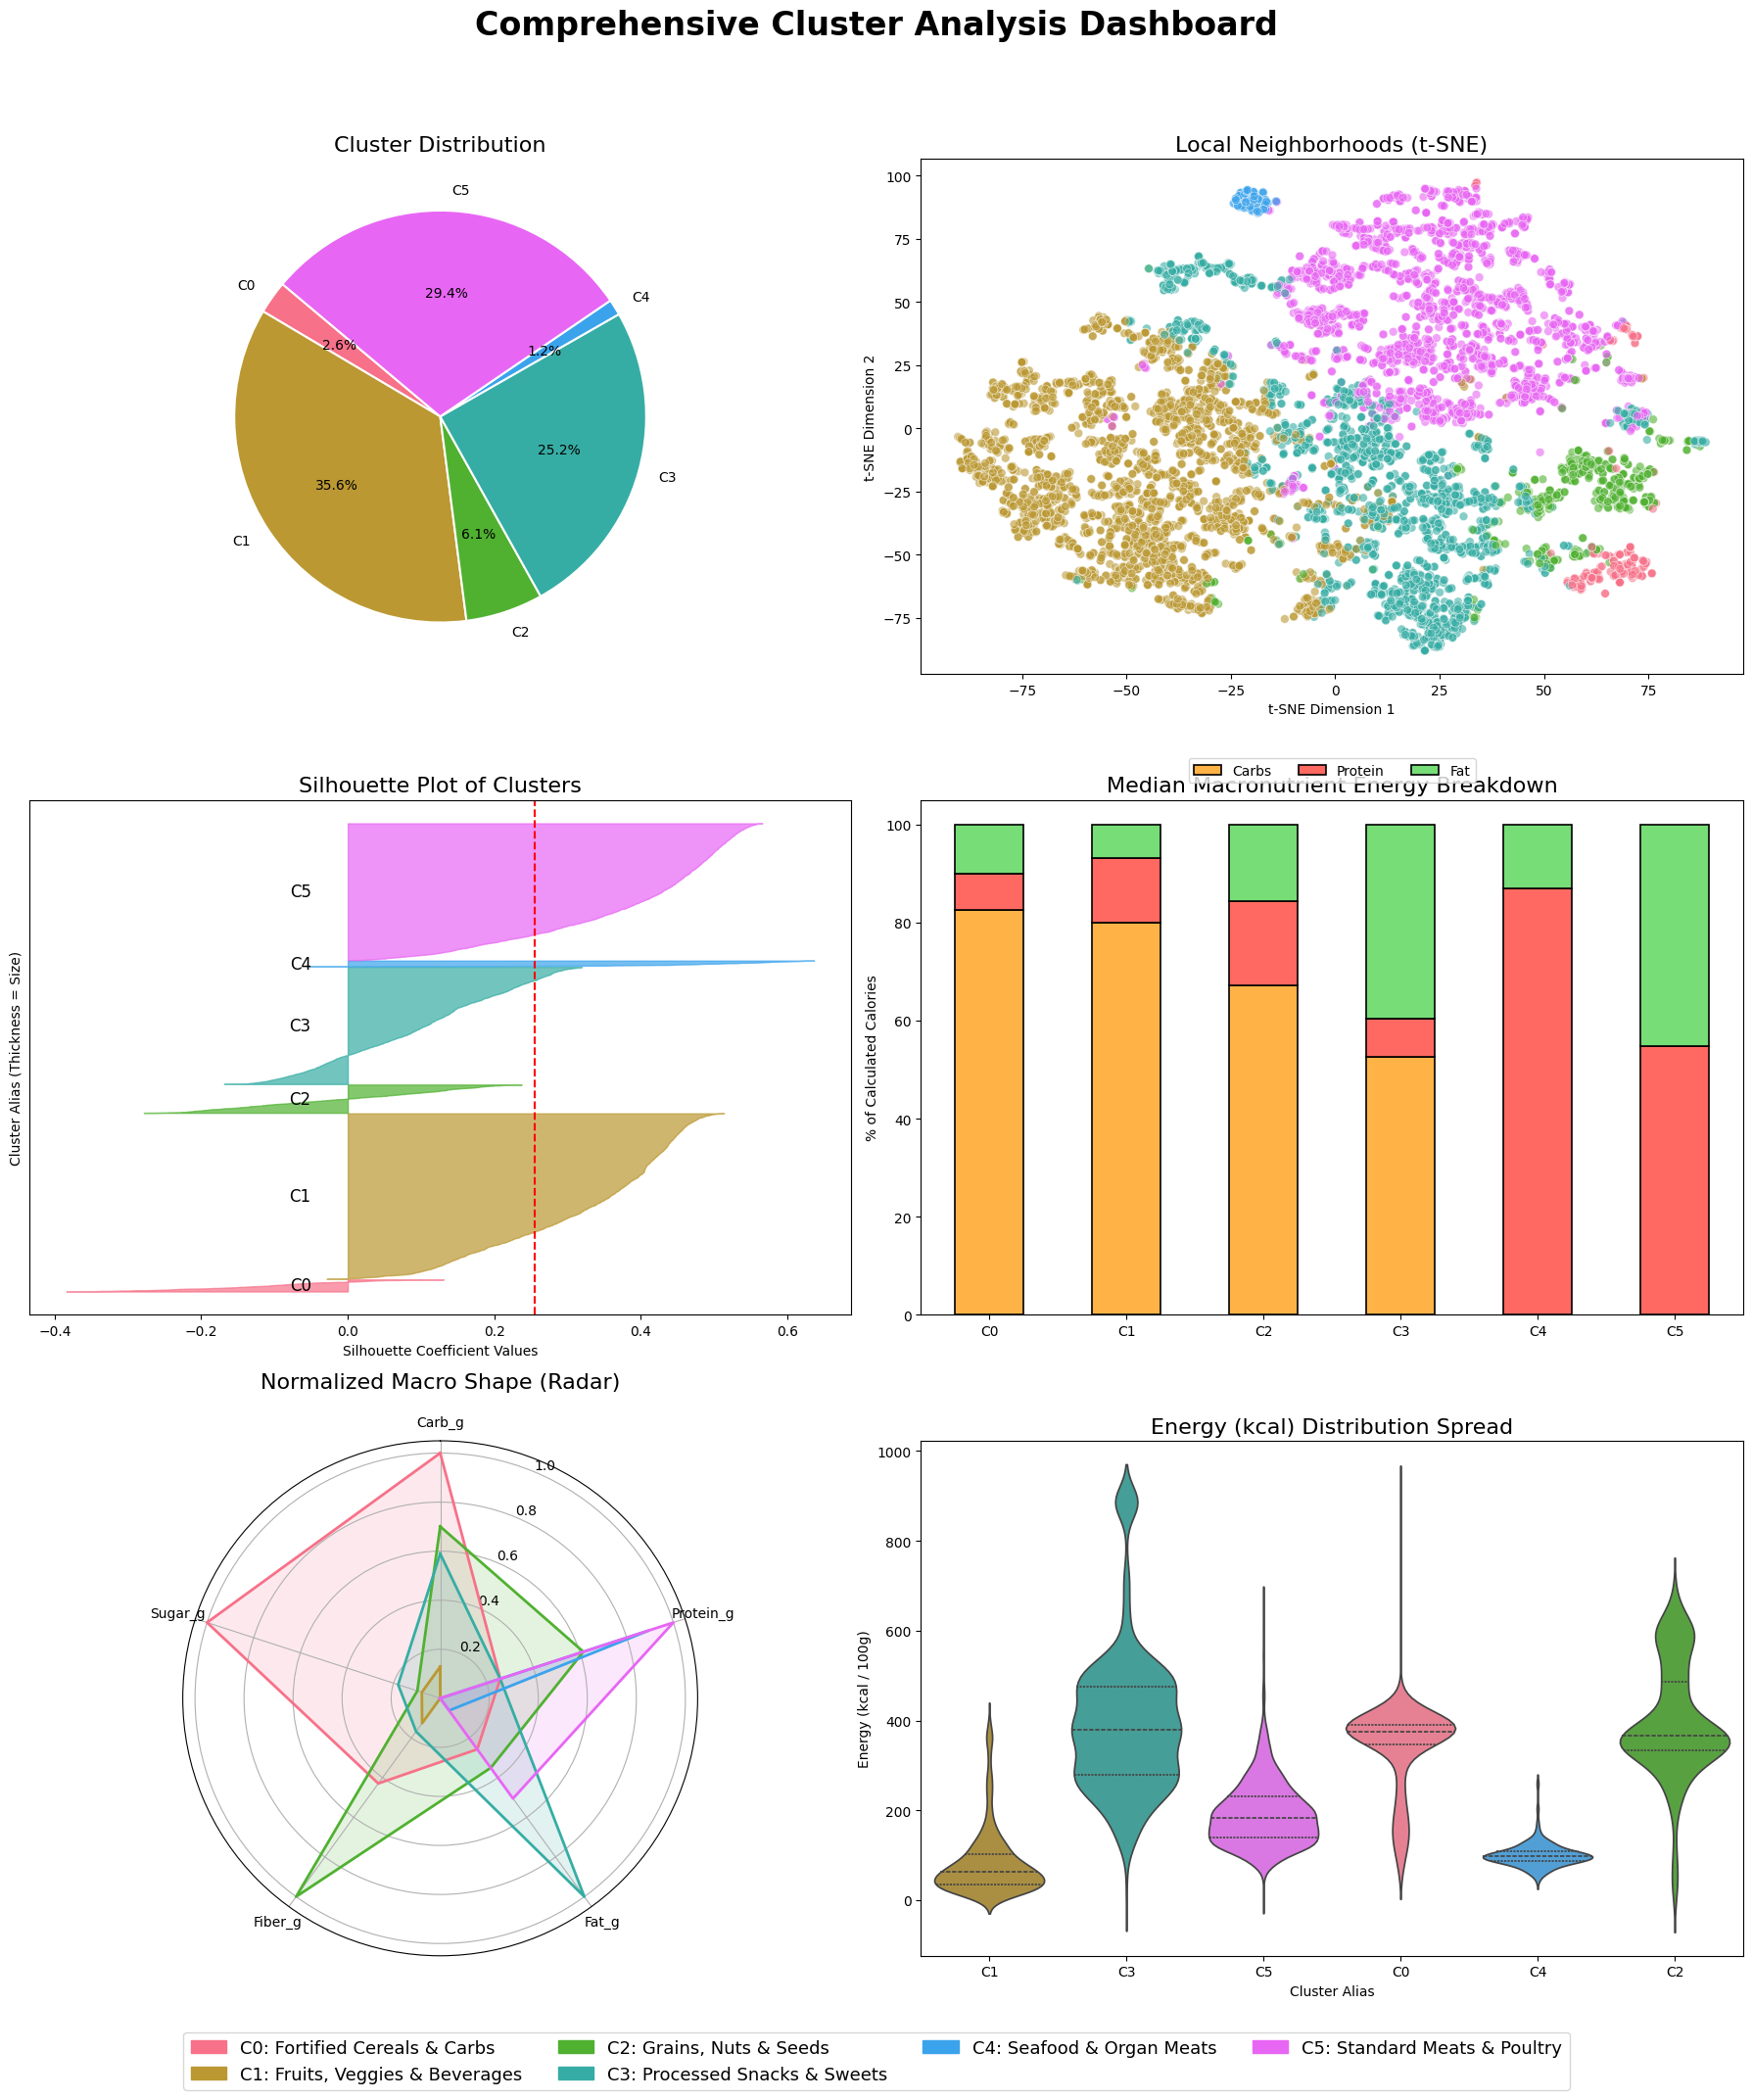

In [22]:
# Name clusters, plot again

cluster_names = {
    0: "Processed Snacks & Sweets",     # High cal, carbs, fat, low fiber
    1: "Seafood & Organ Meats",         # Low cal, pure protein, extreme vitamin density
    2: "Standard Meats & Poultry",      # High protein, moderate fat, zero carb
    3: "Fortified Cereals & Carbs",     # High carb, sugar, extreme mineral/vitamin density
    4: "Grains, Nuts & Seeds",          # Moderate protein, high complex carbs, high fiber
    5: "Fruits, Veggies & Beverages"    # Low cal, low fat/protein, high water content
}

# Map the numeric clusters to their new names
df_results['Cluster_Name'] = df_results['Cluster'].map(cluster_names)

# Reorder columns to make it highly readable
cols = ['NDB_No', 'Descrip', 'Cluster', 'Cluster_Name'] + \
       [c for c in df_results.columns if c not in ['NDB_No', 'Descrip', 'Cluster', 'Cluster_Name']]
df_results = df_results[cols]

evaluate_and_visualize_clusters(X_eng, X_preprocessed, df_results['Cluster_Name'])

### Subclustering
The clustering was a success, however, the largest cluster still makes up more than a third of the original data. Thus we've decided to subcluster the largest cluster (again, with KMeans).
- K=5 produced good results, although one cluster inevitably collapses.

CLUSTER SIZE STATISTICS
                                 Alias  Size (Rows)  Percentage (%)
Cluster                                                            
Dairy Liquids, Formulas & Creams    C0          521           16.00
Fibrous & Green Veggies             C1          789           24.23
Starchy Veggies & Soups             C2         1032           31.70
Sugary Drinks, Juices & Alcohol     C3          910           27.95
Vitamin Outliers (Acerola)          C4            4            0.12




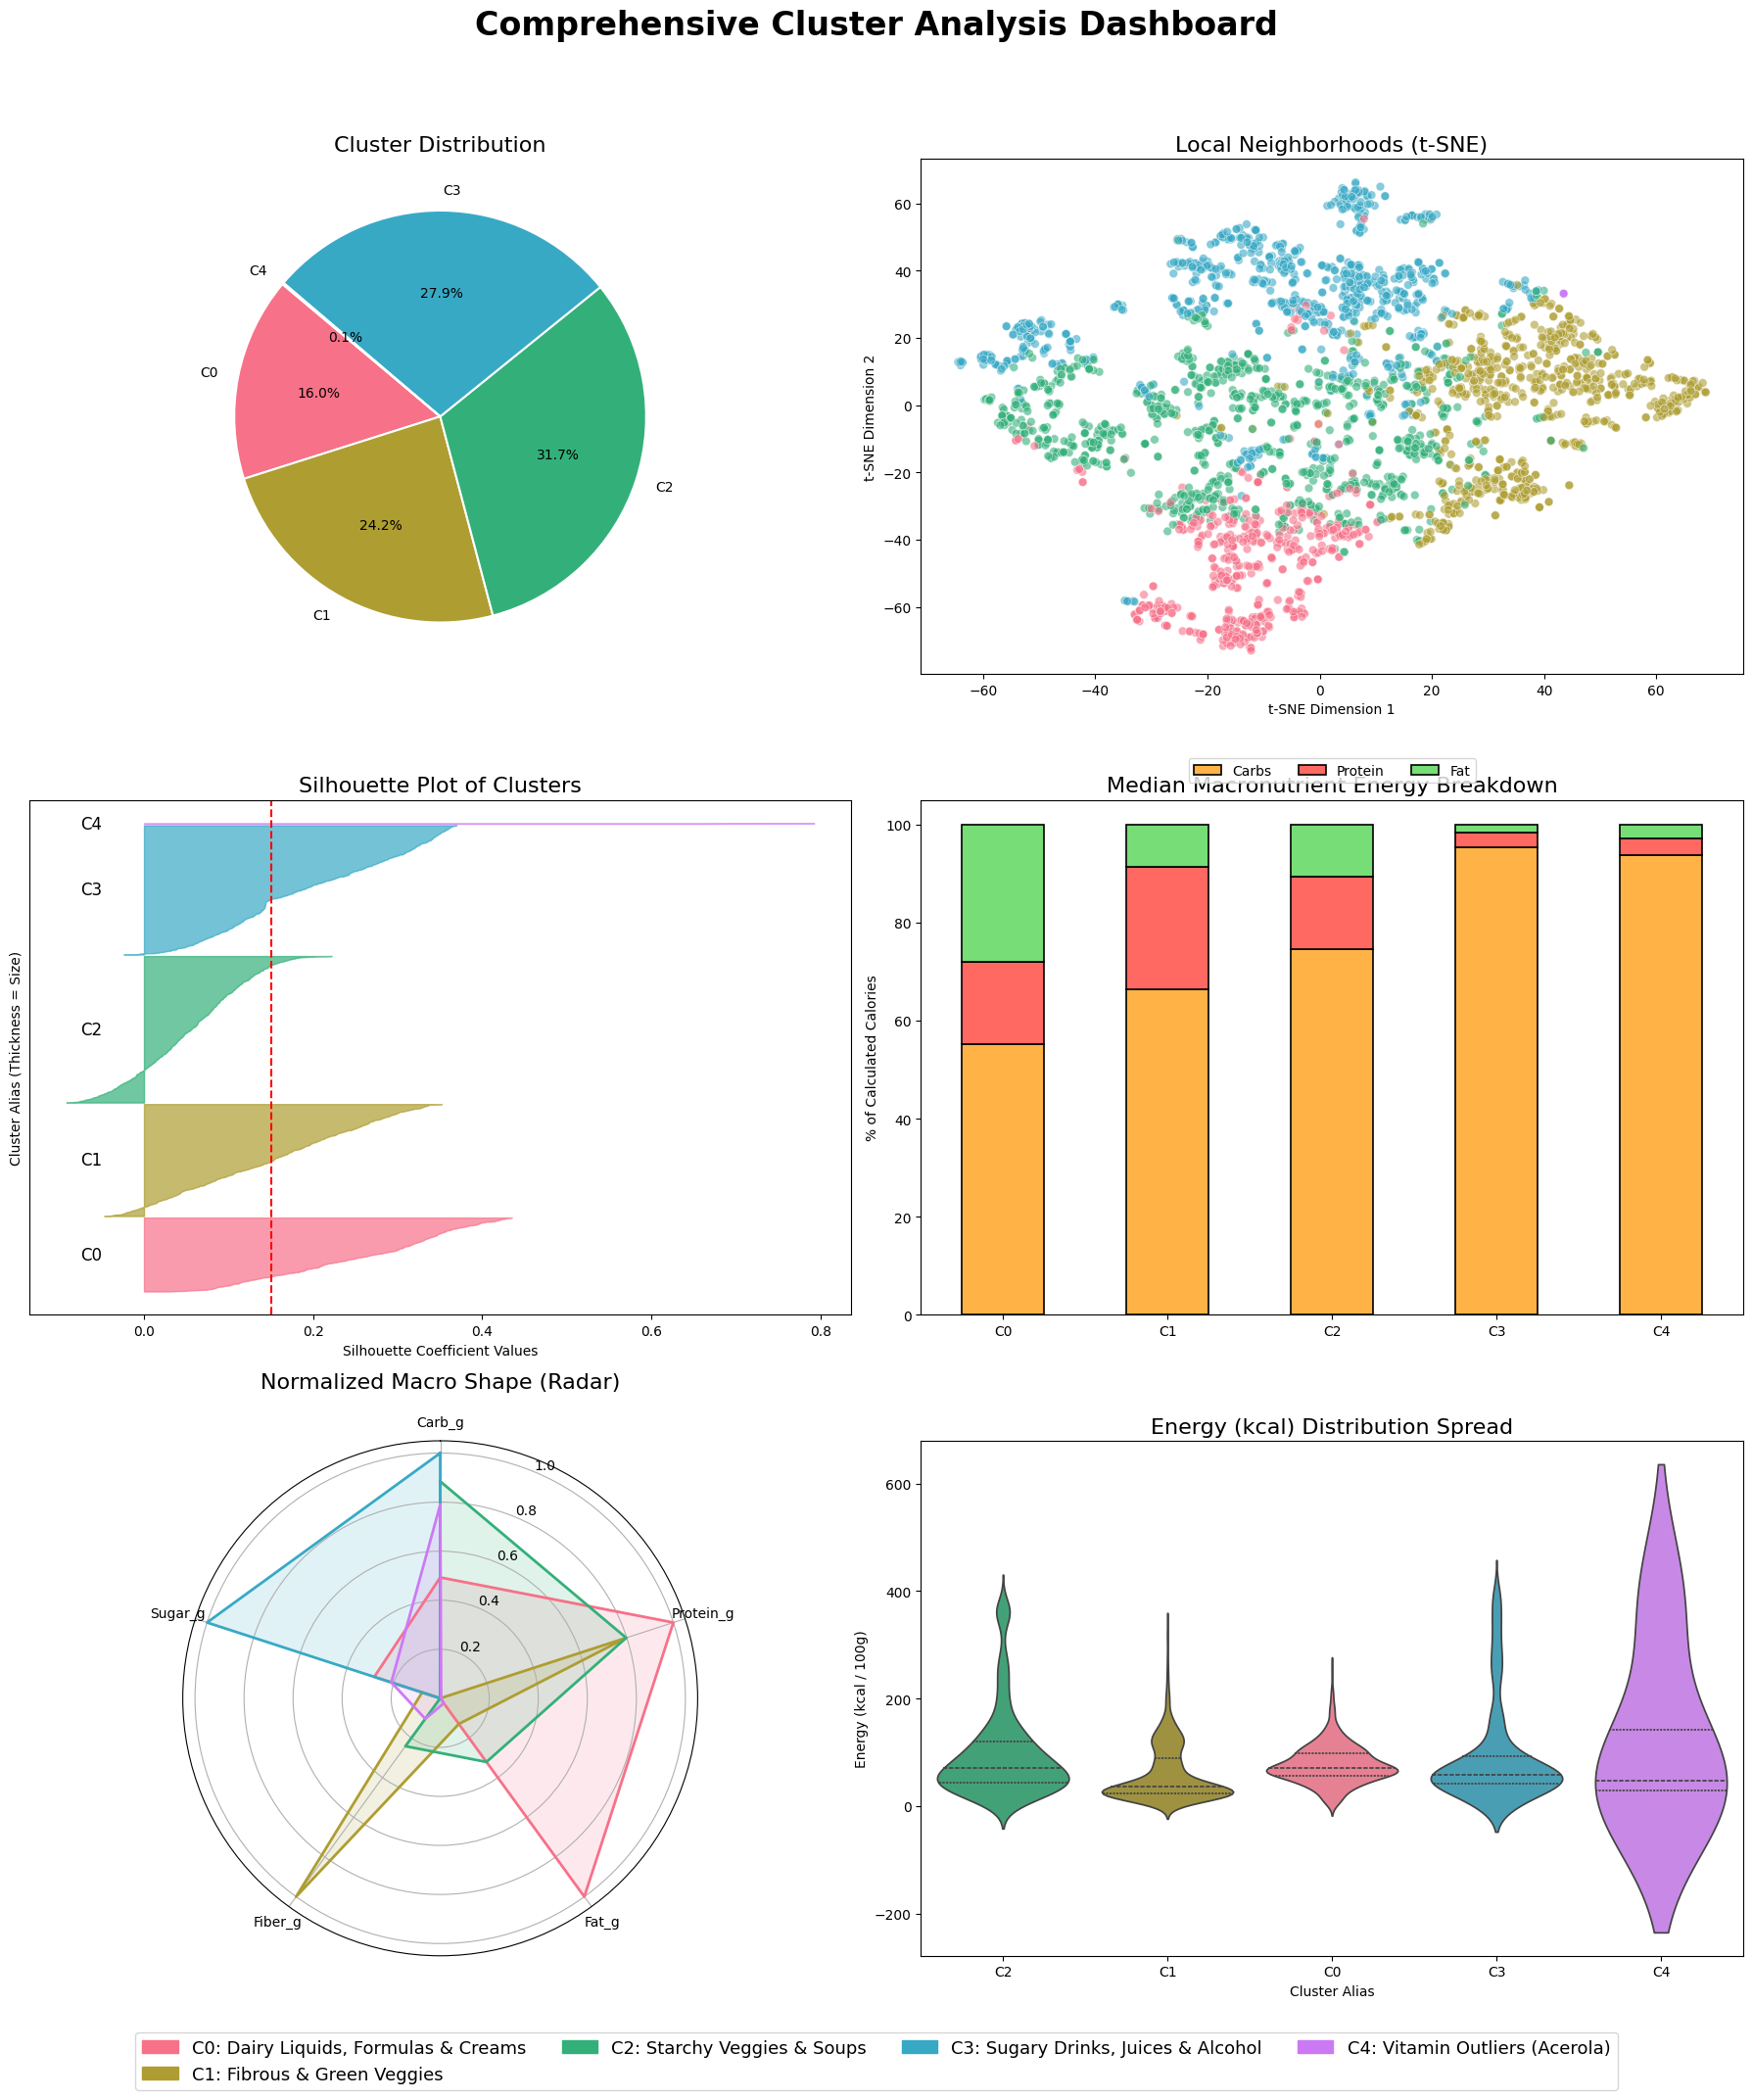


SUB-CLUSTER SAMPLES

--- Sub-Cluster Starchy Veggies & Soups ---
  - soup clam chowder manhattan cnd cond
  - peppers hot chili red cnd excluding seeds solliquids
  - seaweed irishmoss raw
  - corn swt white cnd vacuum pk reg pk
  - winged bean immat seeds ckd bld drnd wsalt
  - wheat flr white (industrial) 15 prot bleached unenr
  - horned melon (kiwano)
  - tky stuffing mshd potato wgravy assorted veg frz microwave

--- Sub-Cluster Fibrous & Green Veggies ---
  - celery stalk
  - cabbage savoy raw
  - broccoli frz chopd unprep
  - babyfood peas dices todd
  - edamame frz unprep
  - okra ckd bld drnd wsalt
  - cardoon ckd bld drnd wsalt
  - peppers serrano raw

--- Sub-Cluster Vitamin Outliers (Acerola) ---
  - acerola (west indian cherry) raw
  - babyfood gerber 2nd foods appl carrot  squash organic
  - acerola juice raw
  - beverages tea grn inst decaffei lemon unswtnd fort w vit c

--- Sub-Cluster Sugary Drinks, Juices & Alcohol ---
  - guava nectar cnd w added vit c
  - beverages

In [23]:
# Isolate the scaled data and the engineered data for just Cluster 5
cluster_5_indices = df_results[df_results['Cluster'] == 5].index

X_preprocessed_c5 = X_preprocessed.loc[cluster_5_indices]
df_c5_results = df_results.loc[cluster_5_indices].copy()

# Hypothesis: it will split into Vegetables, Sugary Fruits/Juices, and Zero-Cal Beverages, ...
k_sub = 5
kmeans_sub = KMeans(n_clusters=k_sub, init='k-means++', random_state=42, n_init="auto")
df_c5_results['Sub_Cluster'] = kmeans_sub.fit_predict(X_preprocessed_c5)

# Rename clusters for better visualizations
sub_cluster_names = {
    0: "Starchy Veggies & Soups",
    1: "Fibrous & Green Veggies",
    2: "Vitamin Outliers (Acerola)",
    3: "Sugary Drinks, Juices & Alcohol",
    4: "Dairy Liquids, Formulas & Creams"
}

df_c5_results['Sub_Cluster_Name'] = df_c5_results['Sub_Cluster'].map(sub_cluster_names)

evaluate_and_visualize_clusters(X_eng.loc[cluster_5_indices], X_preprocessed.loc[cluster_5_indices], df_c5_results['Sub_Cluster_Name'])

# Print random samples from each sub-cluster
print("\n" + "="*50)
print("SUB-CLUSTER SAMPLES")
print("="*50)
for i in range(k_sub):
    print(f"\n--- Sub-Cluster {sub_cluster_names[i]} ---")
    sub_cluster_data = df_c5_results[df_c5_results['Sub_Cluster'] == i]
    
    # Get the sample size based on the actual size of this specific sub-cluster
    sample_size = min(8, len(sub_cluster_data))
    samples = sub_cluster_data['Descrip'].sample(sample_size, random_state=42)
    
    for food in samples.values:
        print(f"  - {food}")

### Interpretation
Based on the hidden mathematical patterns in the data, our model learned to recognize natural human dietary categories with surprising accuracy. An analysis of the learned parameters (the centroid coordinates) reveals that the model did not group foods randomly; instead, it created clusters that mirror real macrobiotic and physical properties. For example, it successfully separated foods with high water content and low energy density (fruits, vegetables) from energy-dense and highly processed foods.

The reason why the model learned exactly this is a direct result of our feature engineering and preprocessing pipeline. The model was highly sensitive to our derived columns, such as the macronutrient calorie ratios and the engineered Fiber_Carb_ratio and Vitamin_density features. Standard K-Means is notoriously sensitive to extreme outliers (e.g., a food with a massive amount of sodium could hijack a centroid and create a meaningless cluster). Because we applied a logarithmic transformation (log1p) to the highly right-skewed mineral distributions and normalized everything using StandardScaler, the model treated all key nutrients with equal mathematical weight. This allowed it to subtly differentiate between "Fibrous & Green Veggies" and "Starchy Veggies," or to identify the tiny "Seafood & Organ Meats" cluster defined by zero carbohydrates but extreme vitamin density.

CLUSTER SIZE STATISTICS
                                 Alias  Size (Rows)  Percentage (%)
Cluster                                                            
Dairy Liquids, Formulas & Creams    C0          521            5.69
Fibrous & Green Veggies             C1          789            8.62
Fortified Cereals & Carbs           C2          237            2.59
Grains, Nuts & Seeds                C3          556            6.07
Processed Snacks & Sweets           C4         2304           25.16
Seafood & Organ Meats               C5          114            1.25
Standard Meats & Poultry            C6         2689           29.37
Starchy Veggies & Soups             C7         1032           11.27
Sugary Drinks, Juices & Alcohol     C8          910            9.94
Vitamin Outliers (Acerola)          C9            4            0.04




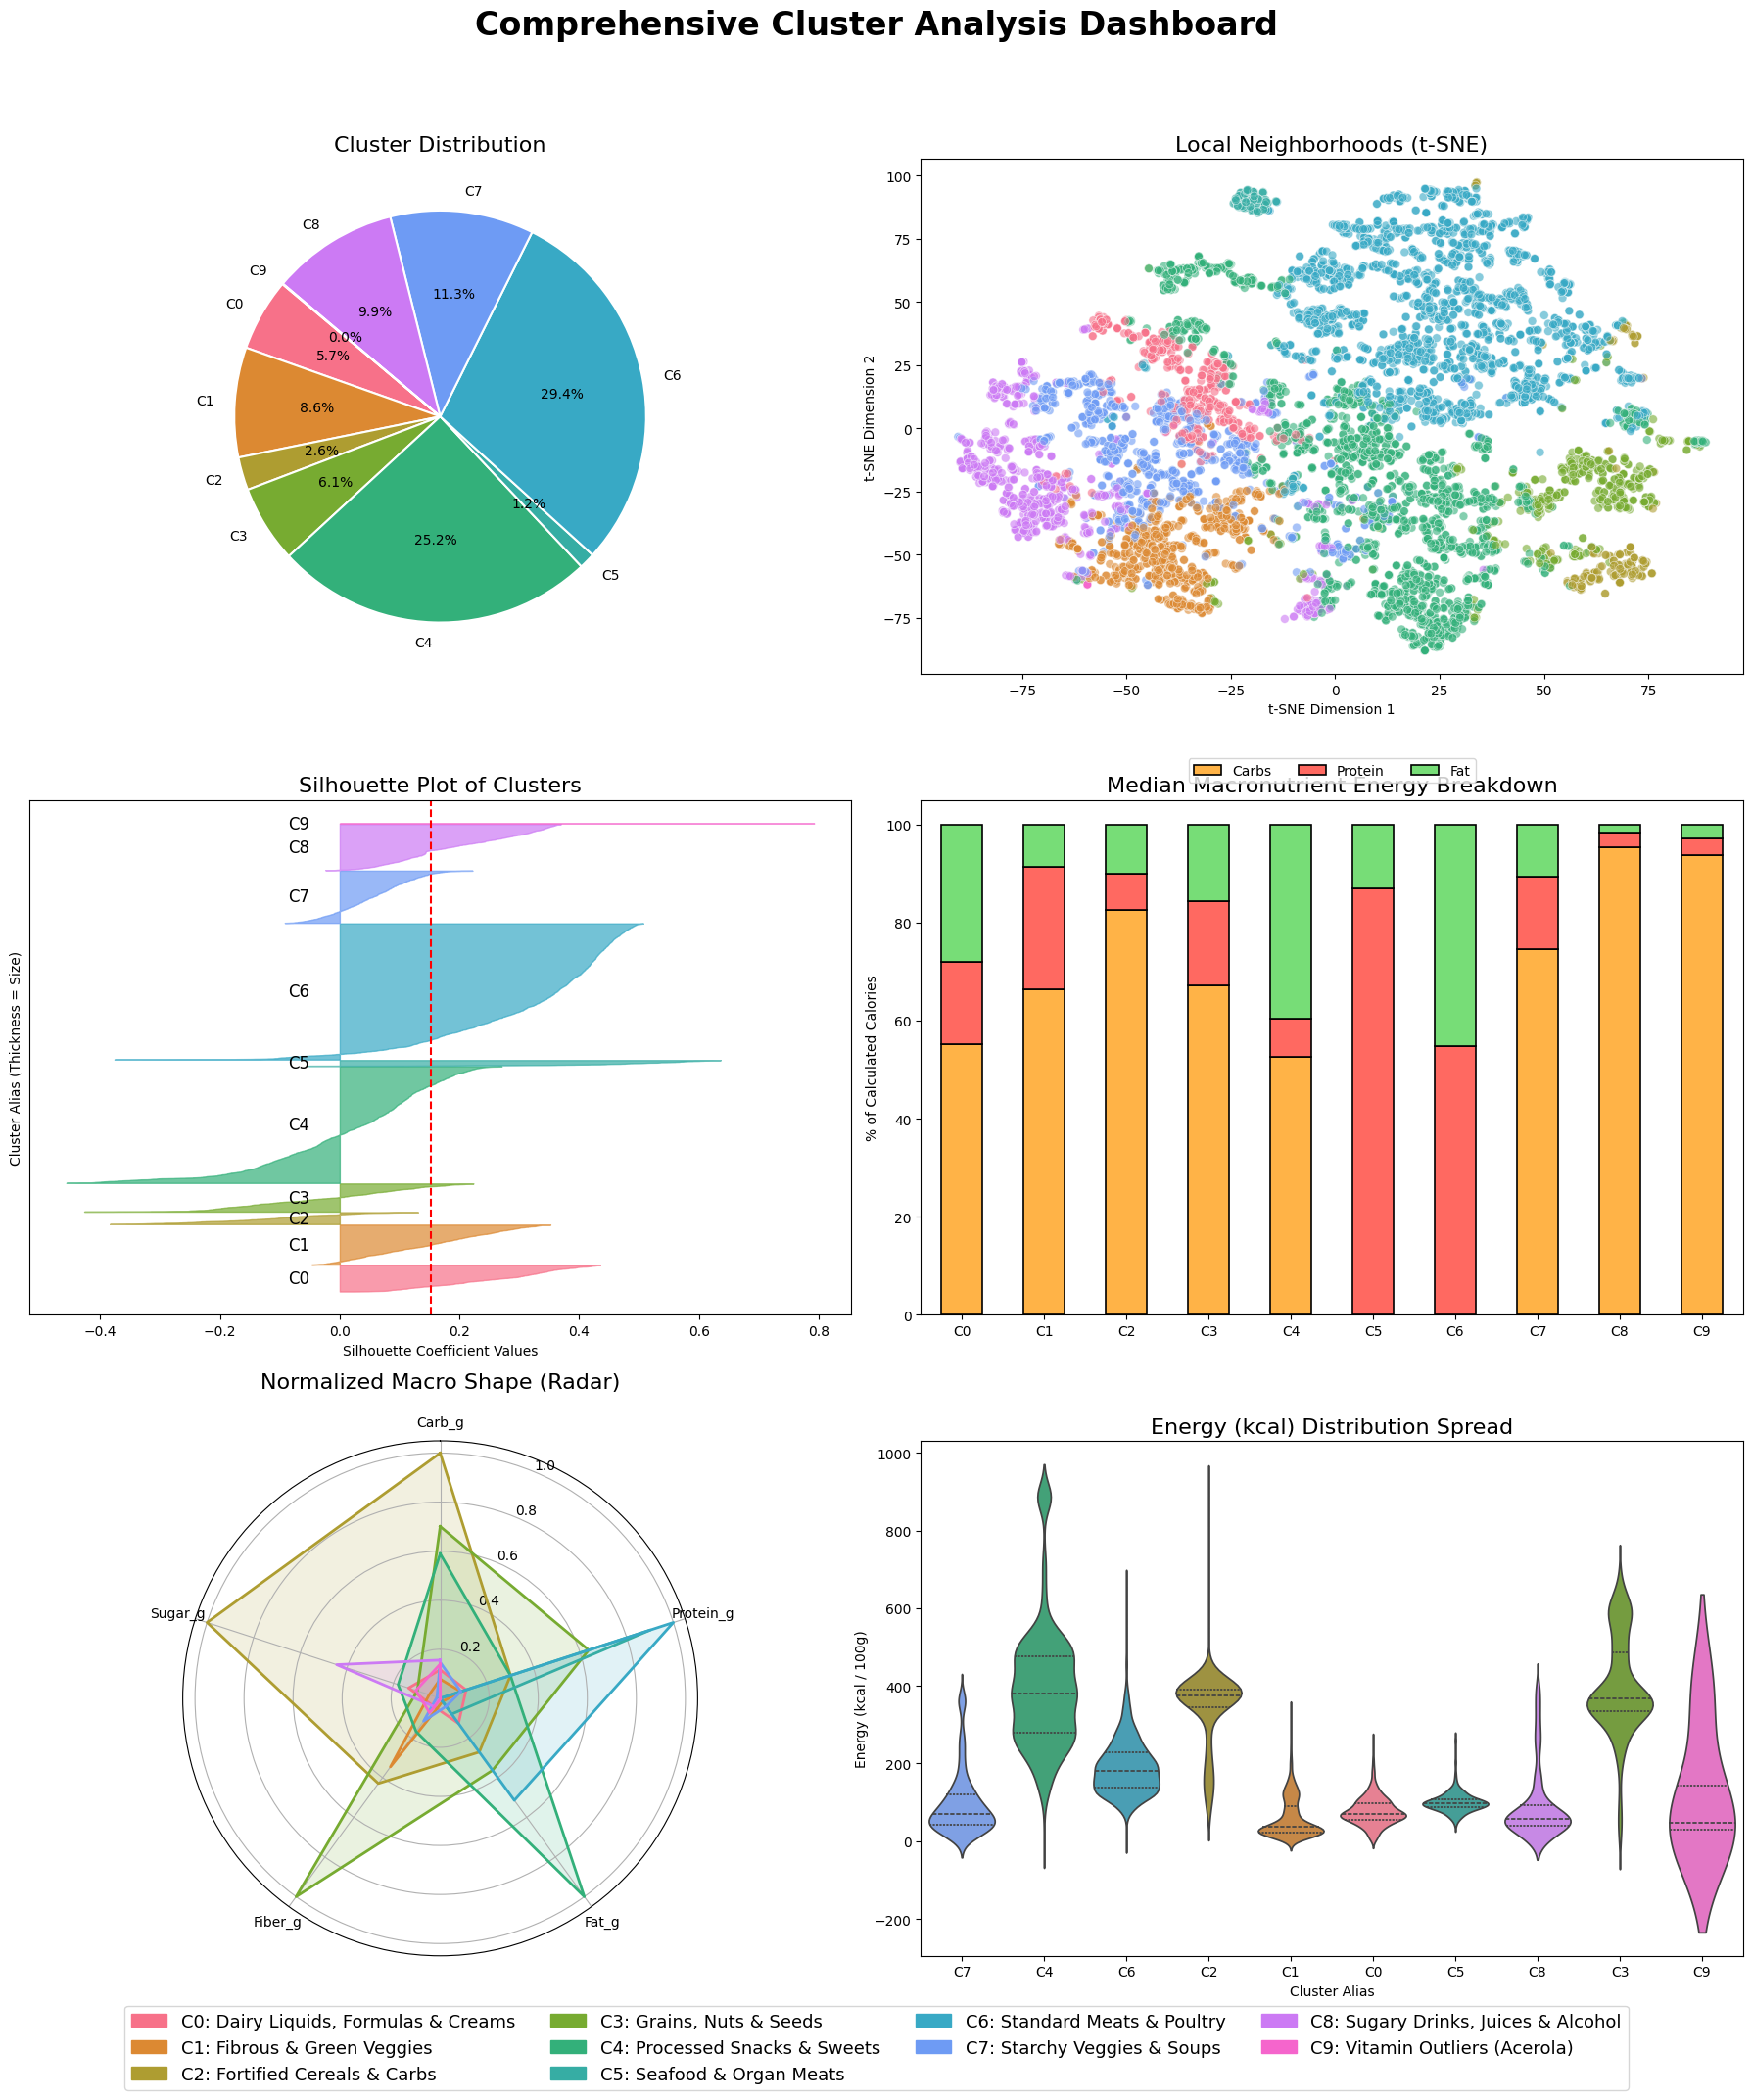

In [24]:
# For rows that aren't in Cluster 5, keep their original Cluster_Name.
# For rows that ARE in Cluster 5, overwrite it with the new Sub_Cluster_Name.
df_results.update(df_c5_results[['Sub_Cluster_Name']].rename(columns={'Sub_Cluster_Name': 'Cluster_Name'}))

evaluate_and_visualize_clusters(X_eng, X_preprocessed, df_results['Cluster_Name'])

### Evaluation
To evaluate the clustering quality, we utilized the Silhouette Score complemented by an analysis of Inertia (Within-Cluster Sum of Squares). Inertia measures the compactness of the clusters; however, it naturally decreases as the number of clusters increases, making it insufficient on its own. The Silhouette Score is much more appropriate for this task because it measures (on a scale from -1 to 1) how close each data point is to its own cluster compared to the nearest neighboring cluster. It therefore accounts for both cluster cohesion and cluster separation. Our choice of $k$ was guided by finding the maximum of this score in combination with the "elbow" method applied to the inertia graph.

In [25]:
# Silhouette Score 
# Measures how similar an object is to its own cluster compared to other clusters.
# Ranges from -1 to +1. A higher score indicates well-separated, dense clusters.
trained_silhouette = silhouette_score(X_preprocessed, df_results['Cluster_Name'])

print(f"Final Number of Clusters (k) : {len(df_results['Cluster_Name'].unique())}")
print(f"Silhouette Score             : {trained_silhouette:.4f}")

Final Number of Clusters (k) : 10
Silhouette Score             : 0.1515


# Conclusion

## Summary

This project successfully developed a nutritional clustering system to organize food ingredients into semantically meaningful categories based on their macronutrient and micronutrient profiles. The comprehensive pipeline included rigorous data preprocessing, exploration of multiple clustering algorithms, and careful hyperparameter optimization.

### Methodology

**Data Preprocessing:** We began with 10250 manually cleaned food records from the USDA nutritional database. After handling missing values, converting micro/milligrams to grams, removing outliers that violated the Atwater caloric equation and removing duplicate rows, we retained 9156 samples with 27 numeric features. Log1p transformation was applied to highly skewed distributions, followed by standard scaling to ensure equal feature weighting. (both are standard techniques in nutritional science)

**Feature Engineering:** We created derived features including macronutrient-calorie ratios, fiber-to-carb ratios, saturated fat ratios, and aggregated mineral/vitamin density scores. These engineered features enabled the model to capture domain-specific nutritional relationships beyond raw nutrient counts.

### Algorithm Comparison:
- **Random Baseline:** Silhouette score = -0.0187 (trivial)
- **DBSCAN:** Good silhouette score ≈ 0.459761 but producing only 4 poorly-interpreted clusters
- **HDBSCAN:** Great silhouette score ≈ 0.282377, 37 density-based clusters with mixed semantic coherence; effective for outlier detection but over-fragmented and hard to interpret.
- **K-Means:** Optimal k=6 with silhouette score ≈ 0.25, producing highly interpretable clusters aligned with real dietary categories. Used further sub-clustering to cluster large clusters further and achieved better interpretable clusters with lower (≈0.16) silhouette score.